# regression_health: predicting next-day symptom severity

Capstone project, Viola Kempa. Dataset: Flaredown Autoimmune Symptom Tracker (Kaggle).

## Problem statement and motivation

People living with autoimmune conditions such as rheumatoid arthritis, lupus, and Crohn's tend to manage flares reactively, responding once symptoms have already worsened. This project asks whether the data patients already self-track can predict next-day symptom severity well enough to support a shift toward preventive self-management.

The target is the next calendar day's mean symptom severity, an ordinal 0 to 4 scale taken from Flaredown's `trackable_value` and treated as a regression target. A reliable day-ahead signal lets a patient pace activity, time a treatment with their clinician, rest before an important day, or simply prepare for a difficult one. The results could inform a gentle in-app heads-up, a short trend a patient chooses to share in a clinical conversation, and guidance to app builders on which data is worth collecting.

Success is defined against a naive "tomorrow equals today" baseline: the model has to beat that persistence baseline on RMSE under an honest temporal hold-out, stay interpretable and light enough to run inside a tracking app, and hold up to checks for leakage and subgroup fairness. The work is a research prototype for self-management, not a medical device, and none of its outputs are intended to gate medication or clinical decisions.

## Hypotheses

H1. A model built on lagged symptom, treatment, and environmental features predicts next-day severity better than the naive persistence baseline, where tomorrow is assumed equal to today.

H2. Recent symptom history is a stronger predictor than environmental triggers, so the disease's own recent trajectory matters more than the weather.

Both hypotheses are tested rather than asserted. H1 is judged against the naive baseline on the untouched 2019 hold-out in Sections 6 and 8. H2 is judged by scoring isolated feature blocks under the same grouped cross-validation in Section 7. Section 10 returns to both by reframing the target from the severity level to the next-day change, which is the harder and more informative version of the question.

## Dataset selection, ethics, and access

**Source.** The data is the Flaredown Autoimmune Symptom Tracker, published on Kaggle by Flaredown, a patient symptom-tracking application. The export is a long event log of about 7.98 million rows from 42,283 users between 2012 and 2019, where each row is one tracked item (a symptom, condition, treatment, food, weather reading, or tag) logged by one user on one day.

**Target and features.** The target is the next calendar day's mean Symptom severity on the 0 to 4 scale. The model inputs are today's mean severity and its one, two, and three day lags, a rolling three-day mean, daily counts of treatments, foods, and tags, mean condition severity, five weather variables, age, and day of week. Section 8 adds two past-only features, a short-term severity trend and a log-compressed symptom count. Free-text item names are reduced to per-type counts and means rather than used directly, which is recorded as a limitation for future work.

**Ethical considerations.** This is sensitive, self-reported health data. It is anonymised at source, but the cohort is self-selected into a tracking app, is roughly 81 percent female, and is skewed toward the United States and United Kingdom, so it is not representative of all patients with these conditions. Fairness across self-reported sex is checked in Section 9, and the limits of that check, including the subgroups that could not be tested, are stated alongside it. The model describes association, not causation, so a high weight on recent severity does not license any claim that changing one input will change tomorrow.

**Licensing.** Use of the dataset is governed by the terms on its Kaggle page, which should be checked before any redistribution. The raw export is not redistributed as part of this submission.

**Access and loading.** To reproduce the project from raw data, download `export.csv` from the Kaggle page, for example with `kaggle datasets download -d flaredown/flaredown-autoimmune-symptom-tracker`, and place it in `data/raw/`. Then run `python src/profile_data.py`, `python src/build_panel.py`, and `python src/make_features.py` to rebuild the daily panel and the leakage-safe train and test splits that this notebook reads. Full provenance, the citation, and the DVC setup for the large raw file are in `references/data_source.md`.

## How this notebook is organised

Sections 1 to 5 cover data understanding, cleaning, and preprocessing (Milestone 3). Sections 6 to 8 cover model development and comparison against the naive baseline (Milestone 4). Section 9 covers evaluation, regularisation, hyperparameter refinement, residual diagnostics, and an ethical reflection on the final model (Milestone 6). Section 10 reframes the target to the next-day change and is where the project's clearest insight sits.

The stakeholder-facing impact report (Milestone 7) is delivered as a separate notebook, `viola_impact_report.ipynb`, in this same folder. It contains the technical summary, a non-technical executive summary, the key visuals, a communication and deployment plan, and a limitations and ethics reflection, and it reproduces every figure and metric from the same leakage-safe splits.

## Working notebook and leakage rule

This is the working capstone notebook for the project framed above. It carries out the data understanding, cleaning, modelling, evaluation, and the change-based analysis in Section 10, running the same steps as the scripted pipeline in `src/`. It reads the already-built daily panel so it stays fast; rebuild it with `python src/build_panel.py` if needed.

**Leakage rule (ToU 'Common Mistakes to Avoid'):** any statistic used for modeling is computed on the training split only, never on the full dataset or the test period.

In [1]:
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PANEL = ROOT / 'data' / 'interim' / 'daily_panel.csv.gz'
pd.set_option('display.max_columns', 50)
print('panel exists:', PANEL.exists())

panel exists: True


## 1. Raw profile (machine-readable)
Full-file profile produced by `src/profile_data.py`.

In [2]:
prof = json.load(open(ROOT / 'reports' / 'profile_result.json'))
print('rows  :', f"{prof['total_rows']:,}")
print('users :', f"{prof['n_users']:,}")
print('dates :', prof['date_min'], '->', prof['date_max'])
print('\nnull rate (%):'); print(pd.Series(prof['null_rate']))
print('\nrows by trackable_type:'); print(pd.Series(prof['type_counts']))

rows  : 7,976,223
users : 42,283
dates : 2012-05-18 00:00:00 -> 2019-12-06 00:00:00

null rate (%):
user_id             0.00
age                 3.88
sex                 1.66
country             3.74
checkin_date        0.00
trackable_id        0.00
trackable_type      0.00
trackable_name      0.00
trackable_value    11.62
dtype: float64

rows by trackable_type:
Symptom      3642279
Weather      1393806
Condition    1111517
Treatment     901820
Food          480971
Tag           445669
HBI              161
dtype: int64


## 2. The target: symptom severity distribution
`Symptom` rows carry an ordinal 0–4 severity. Right-skewed toward low values,
which is why a naive 'tomorrow = today' baseline is already fairly strong.

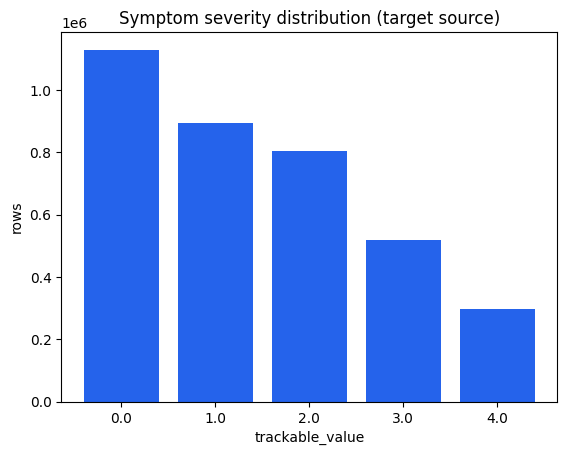

mean 1.439 | median 1.0


In [3]:
h = prof['symptom_value_hist']
plt.bar(list(h.keys()), list(h.values()), color='#2563eb')
plt.title('Symptom severity distribution (target source)')
plt.xlabel('trackable_value'); plt.ylabel('rows'); plt.show()
print('mean', prof['symptom_value_pct']['mean'], '| median', prof['symptom_value_pct']['median'])

## 2b. Descriptive profile of the raw export

Sections 1 and 2 quantify volume and the prediction target. The cells here describe
*content*: which symptoms, conditions, and treatments people log most, who the users
are, and how conditions cluster together. Everything below reads the same
`reports/profile_result.json` produced by `src/profile_data.py` over the full export,
so the notebook stays fast. These are descriptive statistics, not modeling inputs, so
the train-only leakage rule does not apply to them.

### Most-logged trackables by type
Row counts per `trackable_name` for the three modeling-relevant types. Names are free
text, so near-duplicates such as `Fatigue` and `Fatigue and tiredness` coexist; this is
the raw vocabulary the daily panel later collapses into per-type counts and means.

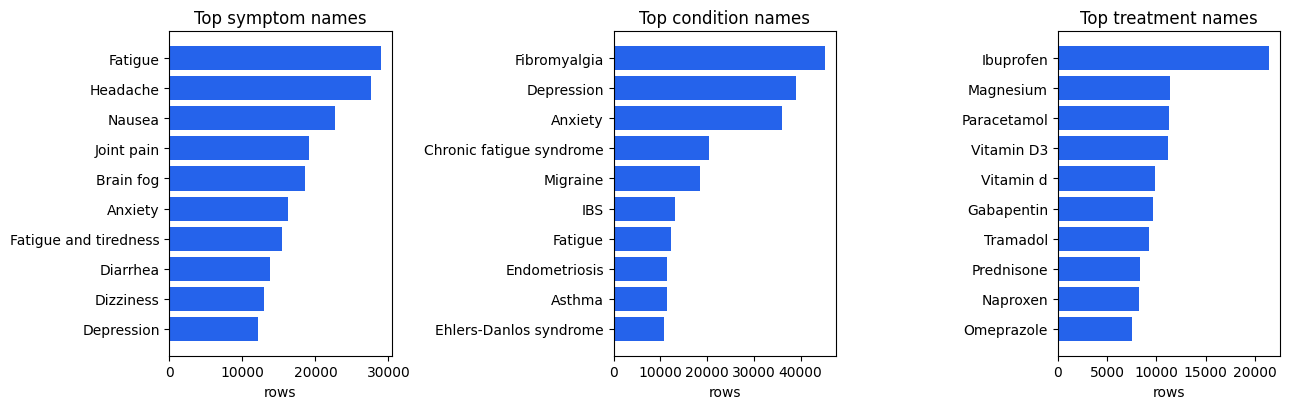

distinct names by type: {'Condition': 8453, 'Food': 8693, 'HBI': 1, 'Symptom': 9148, 'Tag': 9545, 'Treatment': 8155, 'Weather': 6}


In [4]:
FIG = ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
top = prof['top_trackable_names']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, t in zip(axes, ['Symptom', 'Condition', 'Treatment']):
    s = pd.Series(top[t]).head(10)[::-1]
    ax.barh(s.index, s.values, color='#2563eb')
    ax.set_title(f'Top {t.lower()} names'); ax.set_xlabel('rows')
fig.tight_layout(); fig.savefig(FIG / '08_top_trackable_names.png', dpi=110); plt.show()
print('distinct names by type:', prof['n_trackable_names_by_type'])

### Who is in the data
Sex split, the most common countries, and the cleaned age summary. These counts are over
rows, not users, so heavy daily loggers weigh more heavily; the prevalence section below
switches to distinct users for the condition view.

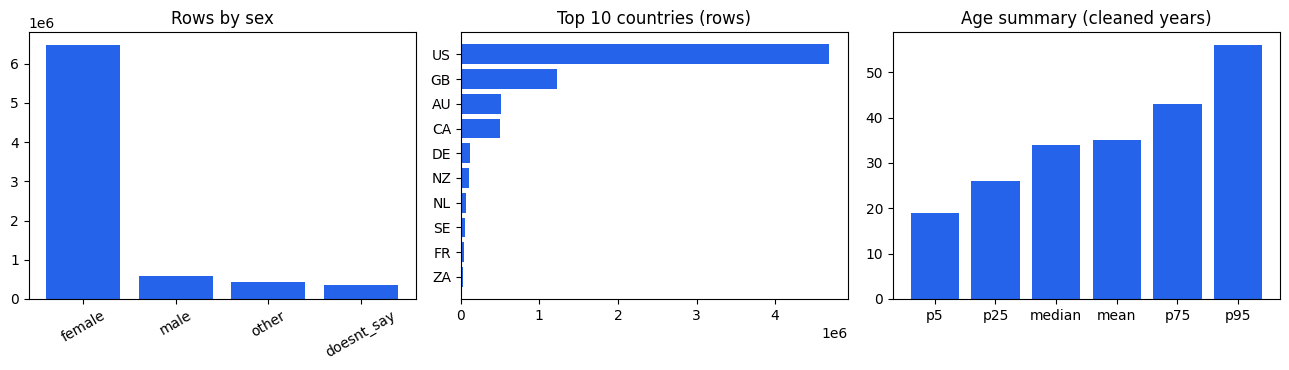

users: 42,283 | countries: 164 | age median 34, p5 to p95 19 to 56


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sx = pd.Series(prof['sex_counts'])
axes[0].bar(sx.index, sx.values, color='#2563eb')
axes[0].set_title('Rows by sex'); axes[0].tick_params(axis='x', rotation=30)
co = pd.Series(prof['country_top20']).head(10)[::-1]
axes[1].barh(co.index, co.values, color='#2563eb'); axes[1].set_title('Top 10 countries (rows)')
a = prof['age_pct']
axes[2].bar(['p5', 'p25', 'median', 'mean', 'p75', 'p95'],
            [a['p5'], a['p25'], a['median'], a['mean'], a['p75'], a['p95']], color='#2563eb')
axes[2].set_title('Age summary (cleaned years)')
fig.tight_layout(); fig.savefig(FIG / '09_demographics.png', dpi=110); plt.show()
print(f"users: {prof['n_users']:,} | countries: {prof['n_countries']} | "
      f"age median {a['median']:.0f}, p5 to p95 {a['p5']:.0f} to {a['p95']:.0f}")

### Condition prevalence (distinct users)
Row counts overweight users who log every day. Counting each user once gives the cohort
size per condition, which is the comparable measure of how common a condition is in the
population and a more honest basis for any per-condition analysis.

users reporting at least one condition: 38,308


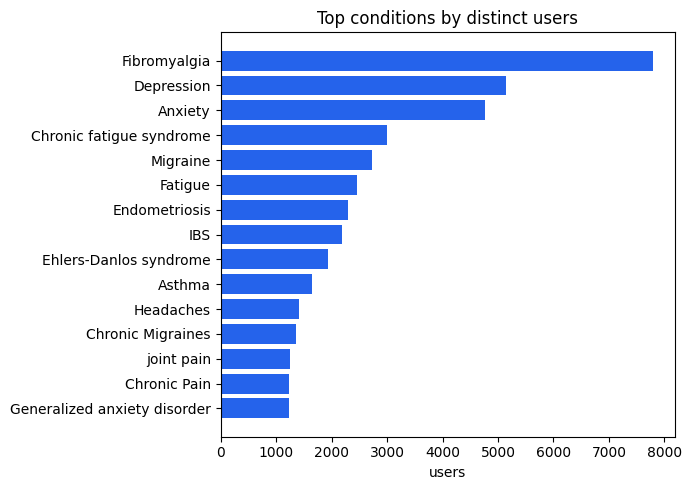

In [6]:
prev = pd.Series(prof['condition_prevalence_users'])
print(f"users reporting at least one condition: {prof['n_users_with_condition']:,}")
fig, ax = plt.subplots(figsize=(7, 5))
s = prev.head(15)[::-1]
ax.barh(s.index, s.values, color='#2563eb')
ax.set_title('Top conditions by distinct users'); ax.set_xlabel('users')
fig.tight_layout(); fig.savefig(FIG / '10_condition_prevalence.png', dpi=110); plt.show()

### Condition co-occurrence
Among the 15 most prevalent conditions, the number of users carrying each pair together.
The autoimmune and chronic-pain conditions cluster (anxiety with depression, fibromyalgia
with chronic fatigue), which is why a per-condition cohort model is a sensible step beyond
the pooled regression in section 6.

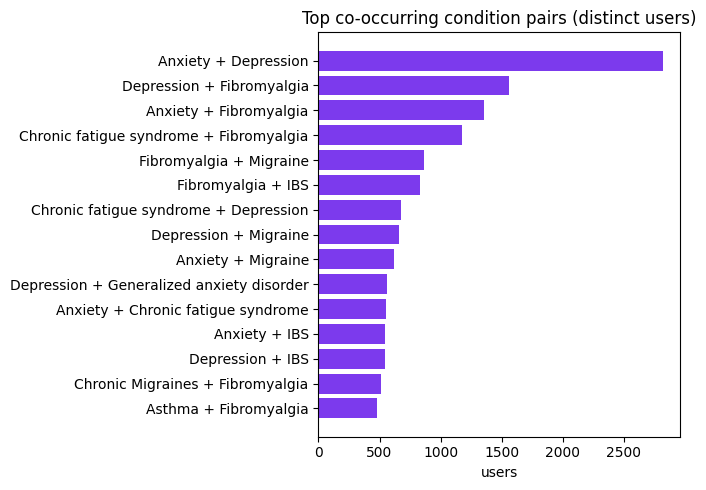

In [7]:
pairs = pd.Series(prof['condition_cooccurrence_users'])
fig, ax = plt.subplots(figsize=(7, 5))
s = pairs.head(15)[::-1]
ax.barh(s.index, s.values, color='#7c3aed')
ax.set_title('Top co-occurring condition pairs (distinct users)'); ax.set_xlabel('users')
fig.tight_layout(); fig.savefig(FIG / '11_condition_cooccurrence.png', dpi=110); plt.show()

## 3. Daily panel: one row per (user, day)
Built by `src/build_panel.py`: long event log → daily features.

In [8]:
p = pd.read_csv(PANEL, parse_dates=['date'])
print(p.shape, '| users:', p['user_id'].nunique())
p.head()

(383228, 18) | users: 42283


,user_id,date,sym_count,sym_mean,sym_max,cond_count,cond_mean,treat_count,food_count,tag_count,humidity,precip_intensity,pressure,temperature_max,temperature_min,age,sex,country
0,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-25,0,NaN,NaN,0,NaN,0,0,0,65.0,0.0000,1023.0,77.0,61.0,42.0,female,US
1,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-26,0,NaN,NaN,0,NaN,0,0,0,73.0,0.0000,1021.0,74.0,62.0,42.0,female,US
2,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-27,0,NaN,NaN,0,NaN,0,0,0,76.0,0.0000,1017.0,78.0,64.0,42.0,female,US
3,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-28,4,3.750000,4.0,1,4.0,2,2,2,82.0,0.0003,1012.0,79.0,67.0,42.0,female,US
4,QEVuQwEA++2fi8XAwh3BnSEwL172Dg==,2019-08-29,7,2.142857,4.0,1,4.0,1,0,0,62.0,0.0001,1015.0,84.0,64.0,42.0,female,US


### Missingness in the daily panel (Step 4)
Column-wise missing counts and percentages, plus whether the weather variables go
missing together. Weather is logged by only a small share of users, so those columns
are largely absent, and that absence is itself a signal about who tracks what rather
than something to impute away without thought.

In [9]:
# Template Step 4: missingness audit on the daily panel.
# The raw profile reports null rates on the long export; the panel is where the model
# actually trains, and the weather block is mostly empty because only a minority of
# users log weather. Absence here is informative, not noise to fill blindly.
miss = pd.DataFrame({
    'missing_count': p.isnull().sum(),
    'missing_pct': (p.isnull().mean() * 100).round(1),
}).sort_values('missing_pct', ascending=False)
print(miss[miss.missing_count > 0])

wx = ['temperature_max', 'temperature_min', 'humidity', 'pressure', 'precip_intensity']
print('\nweather co-missingness (1.0 = always missing together):')
print(p[wx].isnull().corr().round(2))

                  missing_count  missing_pct
precip_intensity         151229         39.5
temperature_min          151024         39.4
temperature_max          151024         39.4
pressure                 151024         39.4
humidity                 151024         39.4
cond_mean                101746         26.5
sym_mean                  74038         19.3
sym_max                   74038         19.3
age                       19813          5.2
country                   16861          4.4
sex                        7234          1.9

weather co-missingness (1.0 = always missing together):
                  temperature_max  temperature_min  humidity  pressure  \
temperature_max               1.0              1.0       1.0       1.0   
temperature_min               1.0              1.0       1.0       1.0   
humidity                      1.0              1.0       1.0       1.0   
pressure                      1.0              1.0       1.0       1.0   
precip_intensity              1.0

### Data-quality check: `age` (fixed upstream)
Raw `age` contains impossible values, both negatives and birth years such as 2018.
`src/build_panel.py` sets anything outside [5, 120] to NaN before the split, so the
panel loaded here is already clean. Out-of-range values become missing rather than
being clipped to a bound, which avoids piling artificial spikes onto the edges. The
cell below confirms the fix held.

In [10]:
print('panel age range:', p['age'].min(), '->', p['age'].max())
print('rows still outside [5,120]:', int(((p['age'] < 5) | (p['age'] > 120)).sum()))
print('age missing (incl. fixed impossibles):', int(p['age'].isnull().sum()))
p['age'].describe()

panel age range: 5.0 -> 118.0
rows still outside [5,120]: 0
age missing (incl. fixed impossibles): 19813


count    363415.000000
mean         34.980606
std          11.368502
min           5.000000
25%          26.000000
50%          33.000000
75%          42.000000
max         118.000000
Name: age, dtype: float64

## 4. Check-in volume over time
Sparse, irregular per-user time series, which motivates a temporal split and a
strictly-next-calendar-day target.

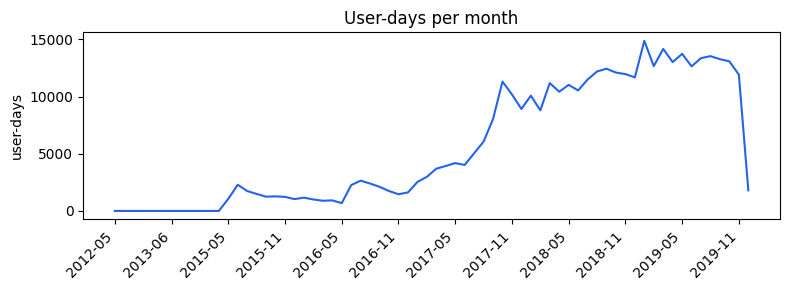

In [11]:
by = p['date'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(8,3)); plt.plot([str(x) for x in by.index], by.values, color='#2563eb')
plt.xticks(range(0, len(by), 6), [str(by.index[i]) for i in range(0, len(by), 6)], rotation=45, ha='right')
plt.title('User-days per month'); plt.ylabel('user-days'); plt.tight_layout(); plt.show()

## 5. Build the next-day target + lagged history (H1 / H2 features)

In [12]:
p = p.sort_values(['user_id', 'date'])
g = p.groupby('user_id')['sym_mean']
for k in (1, 2, 3):
    p[f'lag{k}_sym'] = g.shift(k)
# next calendar day's mean severity
nxt = p[['user_id', 'date', 'sym_mean']].copy()
nxt['date'] -= pd.Timedelta(days=1)
p = p.merge(nxt.rename(columns={'sym_mean': 'target'}), on=['user_id', 'date'], how='left')
data = p[p['target'].notna() & p['sym_mean'].notna()]
print('modeling rows:', len(data))
data[['sym_mean', 'lag1_sym', 'lag2_sym', 'lag3_sym', 'target']].corr()['target']

modeling rows: 214388


sym_mean    0.790930
lag1_sym    0.751834
lag2_sym    0.732244
lag3_sym    0.723776
target      1.000000
Name: target, dtype: float64

### Feature summary table (Step 5)
Type, missingness, cardinality, and a one-line description for each model input. This
is the map the cleaning and modelling decisions below refer back to.

In [13]:
# Template Step 5: feature summary table for the model inputs.
desc = {
    'sym_mean': 'mean symptom severity logged today (0-4)',
    'lag1_sym': 'mean severity 1 recorded day back',
    'lag2_sym': 'mean severity 2 recorded days back',
    'lag3_sym': 'mean severity 3 recorded days back',
    'sym_count': 'number of symptoms logged today',
    'cond_mean': 'mean condition severity today (0-4)',
    'treat_count': 'number of treatments logged today',
    'food_count': 'number of foods logged today',
    'tag_count': 'number of lifestyle tags logged today',
    'temperature_max': 'daily maximum temperature',
    'temperature_min': 'daily minimum temperature',
    'humidity': 'daily humidity',
    'pressure': 'daily barometric pressure',
    'precip_intensity': 'daily precipitation intensity',
    'age': 'user age, cleaned to [5, 120]',
}
feats = list(desc)
summary = pd.DataFrame({
    'feature': feats,
    'dtype': [str(data[c].dtype) for c in feats],
    'missing_pct': [round(data[c].isnull().mean() * 100, 1) for c in feats],
    'n_unique': [int(data[c].nunique()) for c in feats],
    'description': [desc[c] for c in feats],
})
summary

,feature,dtype,missing_pct,n_unique,description
0,sym_mean,float64,0.0,3354,mean symptom severity logged today (0-4)
1,lag1_sym,float64,9.8,3229,mean severity 1 recorded day back
2,lag2_sym,float64,13.5,3195,mean severity 2 recorded days back
3,lag3_sym,float64,16.6,3173,mean severity 3 recorded days back
4,sym_count,int64,0.0,126,number of symptoms logged today
5,cond_mean,float64,15.8,778,mean condition severity today (0-4)
6,treat_count,int64,0.0,52,number of treatments logged today
7,food_count,int64,0.0,47,number of foods logged today
8,tag_count,int64,0.0,42,number of lifestyle tags logged today
9,temperature_max,float64,39.4,137,daily maximum temperature


## 5c. EDA on the leakage-safe training split

The cells above read the full export and the daily panel. The checklist below re-runs on the
training rows only, meaning rows before the 2019-01-01 split, because any statistic that
guides preprocessing or feature selection must never see the test period. The pass covers a
basic overview, a target deep dive, numeric and categorical profiling, a missing-data map, an
IQR outlier screen, a multicollinearity check, and a persisted preprocessing recipe. Plots
use matplotlib only, so no extra dependency is added beyond the existing stack.

In [14]:
# Template basic overview, computed on the training split only.
# Reason the curriculum overview, target dive, and feature profiling must see train rows
# only (date < 2019-01-01) so nothing about the 2019 test period leaks into any decision.
FIG = ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
SPLIT = pd.Timestamp('2019-01-01')
NUM = ['sym_mean', 'lag1_sym', 'lag2_sym', 'lag3_sym', 'sym_count', 'cond_mean',
       'treat_count', 'food_count', 'tag_count', 'temperature_max', 'temperature_min',
       'humidity', 'pressure', 'precip_intensity', 'age']
CAT = ['sex', 'country']
tr = data[data['date'] < SPLIT].copy()
y_tr = tr['target']

print('all modeling rows :', len(data))
print('train rows (<2019):', len(tr), '| users:', tr['user_id'].nunique())
print('numeric features  :', len(NUM), '| categorical:', len(CAT), '| samples:', len(tr))
print('full-row duplicates:', int(tr.duplicated().sum()),
      '(user and date make each row unique, so zero is expected)')
print('sample size is well above the 100-row floor' if len(tr) > 100 else 'TOO FEW ROWS')
print()
tr[NUM].info()

all modeling rows : 214388
train rows (<2019): 128555 | users: 9252
numeric features  : 15 | categorical: 2 | samples: 128555
full-row duplicates: 0 (user and date make each row unique, so zero is expected)
sample size is well above the 100-row floor

<class 'pandas.core.frame.DataFrame'>
Index: 128555 entries, 48 to 383212
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sym_mean          128555 non-null  float64
 1   lag1_sym          115143 non-null  float64
 2   lag2_sym          109946 non-null  float64
 3   lag3_sym          105768 non-null  float64
 4   sym_count         128555 non-null  int64  
 5   cond_mean         111316 non-null  float64
 6   treat_count       128555 non-null  int64  
 7   food_count        128555 non-null  int64  
 8   tag_count         128555 non-null  int64  
 9   temperature_max   82361 non-null   float64
 10  temperature_min   82361 non-null   float64
 11  humidity    

In [15]:
# Min, max, and quartiles per numeric feature on the train split.
tr[NUM].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

,mean,std,min,25%,50%,75%,max
sym_mean,1.47,0.84,0.0,0.84,1.38,2.00,4.00
lag1_sym,1.44,0.83,0.0,0.83,1.33,2.00,4.00
lag2_sym,1.43,0.82,0.0,0.82,1.33,2.00,4.00
lag3_sym,1.42,0.82,0.0,0.81,1.33,1.96,4.00
sym_count,12.35,9.77,1.0,6.00,10.00,16.00,134.00
cond_mean,1.70,0.98,0.0,1.00,1.67,2.33,4.00
treat_count,2.78,4.67,0.0,0.00,1.00,4.00,57.00
food_count,1.49,3.06,0.0,0.00,0.00,2.00,93.00
tag_count,1.55,2.25,0.0,0.00,1.00,2.00,59.00
temperature_max,64.14,18.73,-16.0,50.00,66.00,79.00,118.00


### Target deep dive

The target is next calendar day mean symptom severity on the train split. It is a daily mean,
so it is continuous on the 0–4 scale rather than the integer source values shown in section 2.
A right tail toward low severity is expected, which is why the naive carry-forward baseline in
section 6 is already strong.

mean 1.448 | median 1.353 | std 0.831 | min 0.000 | max 4.000
missing in target: 0
skew 0.58 (positive confirms the right tail, mean sits above median)


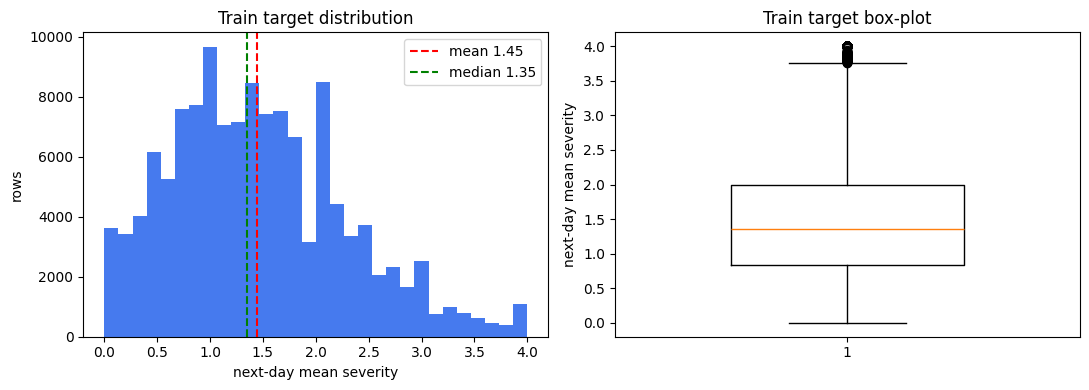

In [16]:
m, md, sd = y_tr.mean(), y_tr.median(), y_tr.std()
print(f'mean {m:.3f} | median {md:.3f} | std {sd:.3f} | min {y_tr.min():.3f} | max {y_tr.max():.3f}')
print('missing in target:', int(y_tr.isnull().sum()))
print(f'skew {y_tr.skew():.2f} (positive confirms the right tail, mean sits above median)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(y_tr, bins=30, color='#2563eb', alpha=0.85)
ax[0].axvline(m, color='red', ls='--', label=f'mean {m:.2f}')
ax[0].axvline(md, color='green', ls='--', label=f'median {md:.2f}')
ax[0].set_title('Train target distribution'); ax[0].set_xlabel('next-day mean severity')
ax[0].set_ylabel('rows'); ax[0].legend()
ax[1].boxplot(y_tr, vert=True, widths=0.5)
ax[1].set_title('Train target box-plot'); ax[1].set_ylabel('next-day mean severity')
fig.tight_layout(); fig.savefig(FIG / '12_target_train_dist.png', dpi=110); plt.show()

### Numeric features, correlation, and missingness

Distribution shape, linear association with the target, and missingness for the fifteen
numeric inputs. Heavy right skew in the count features motivates the transform column of the
recipe at the end of the section.

zero-variance features: none

most skewed features by absolute skew:
precip_intensity    27.87
food_count           3.59
treat_count          3.36
sym_count            2.89
tag_count            2.66
humidity             0.99
dtype: float64


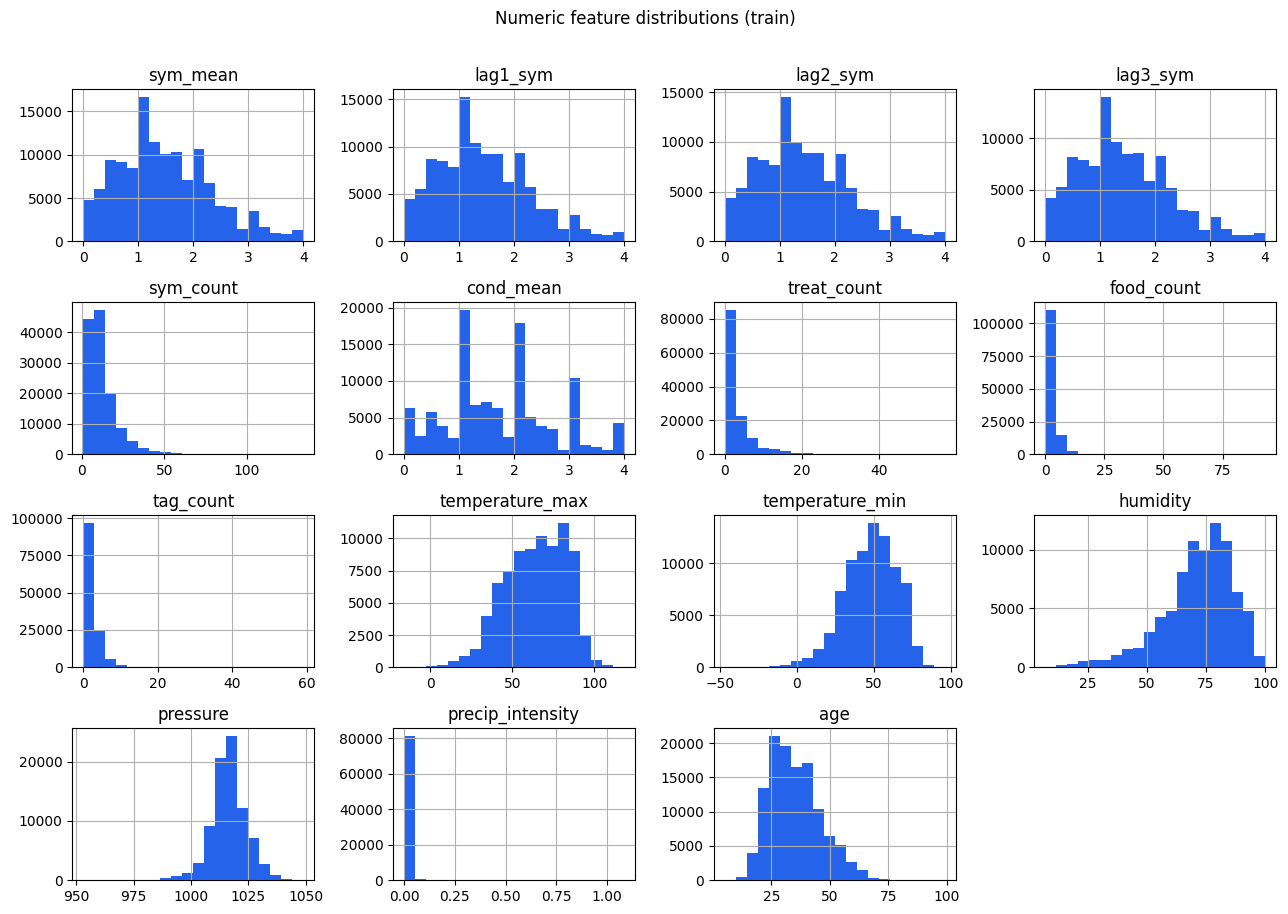

In [17]:
zv = [c for c in NUM if tr[c].nunique() <= 1]
print('zero-variance features:', zv if zv else 'none')
print('\nmost skewed features by absolute skew:')
print(tr[NUM].skew().abs().sort_values(ascending=False).round(2).head(6))

tr[NUM].hist(bins=20, figsize=(13, 9), color='#2563eb')
plt.suptitle('Numeric feature distributions (train)', y=1.01)
plt.tight_layout(); plt.savefig(FIG / '13_feature_histograms.png', dpi=110); plt.show()

Pearson correlation with the target (train):
sym_mean            0.786
lag1_sym            0.746
lag2_sym            0.725
lag3_sym            0.716
cond_mean           0.584
tag_count           0.071
sym_count          -0.066
treat_count        -0.041
age                -0.025
pressure           -0.024
humidity            0.014
food_count         -0.008
precip_intensity    0.004
temperature_max    -0.002
temperature_min    -0.000
dtype: float64


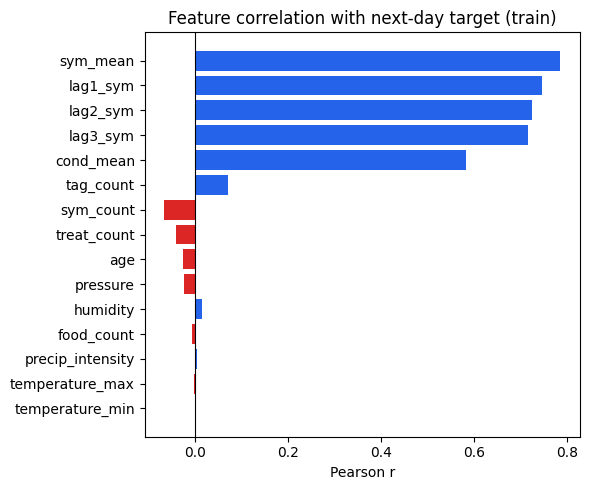

In [18]:
corrs = tr[NUM].corrwith(y_tr).sort_values(key=abs, ascending=False)
print('Pearson correlation with the target (train):')
print(corrs.round(3))

order = corrs.reindex(corrs.abs().sort_values().index)
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(order.index, order.values,
        color=['#dc2626' if v < 0 else '#2563eb' for v in order.values])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature correlation with next-day target (train)'); ax.set_xlabel('Pearson r')
fig.tight_layout(); fig.savefig(FIG / '14_corr_with_target.png', dpi=110); plt.show()

missing pct per numeric feature (train):
temperature_max     35.9
temperature_min     35.9
humidity            35.9
pressure            35.9
precip_intensity    35.9
lag3_sym            17.7
lag2_sym            14.5
cond_mean           13.4
lag1_sym            10.4
age                  7.5
dtype: float64


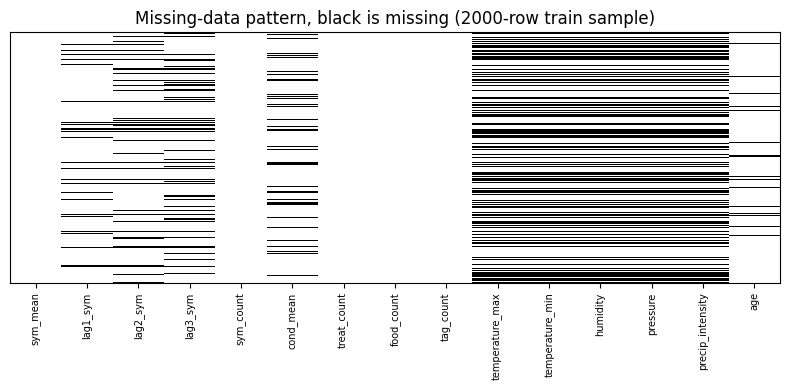

In [19]:
miss = (tr[NUM].isnull().mean() * 100).round(1).sort_values(ascending=False)
print('missing pct per numeric feature (train):')
print(miss[miss > 0] if (miss > 0).any() else 'none missing')

samp = tr[NUM].isnull().sample(n=min(2000, len(tr)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(samp.values, aspect='auto', cmap='Greys', interpolation='nearest')
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM, rotation=90, fontsize=7)
ax.set_yticks([])
ax.set_title('Missing-data pattern, black is missing (2000-row train sample)')
fig.tight_layout(); fig.savefig(FIG / '15_missing_map.png', dpi=110); plt.show()

### Outliers and multicollinearity

An IQR screen flags heavy-tailed features, and the feature-feature correlation matrix flags
redundant pairs. Both matter because section 6 fits an unregularised linear model, where wide
tails and collinear inputs make coefficients unstable even when the pooled RMSE looks fine.

In [20]:
def iqr_outlier_pct(s):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 1)

out = pd.Series({c: iqr_outlier_pct(tr[c]) for c in NUM}).sort_values(ascending=False)
print('IQR outlier pct per feature (train):')
print(out)
print('\nThe count features carry the highest rates. These are genuine heavy-tailed counts,')
print('not data errors, so robust scaling or a log transform is the lever, not row removal.')

IQR outlier pct per feature (train):
precip_intensity    14.1
food_count          10.4
treat_count          6.3
tag_count            5.7
sym_count            4.6
pressure             3.3
humidity             3.1
sym_mean             1.2
lag3_sym             1.1
lag1_sym             1.0
lag2_sym             1.0
temperature_min      0.8
age                  0.5
temperature_max      0.2
cond_mean            0.0
dtype: float64

The count features carry the highest rates. These are genuine heavy-tailed counts,
not data errors, so robust scaling or a log transform is the lever, not row removal.


feature pairs with absolute r above 0.8 (train):
  temperature_max ~ temperature_min: 0.92


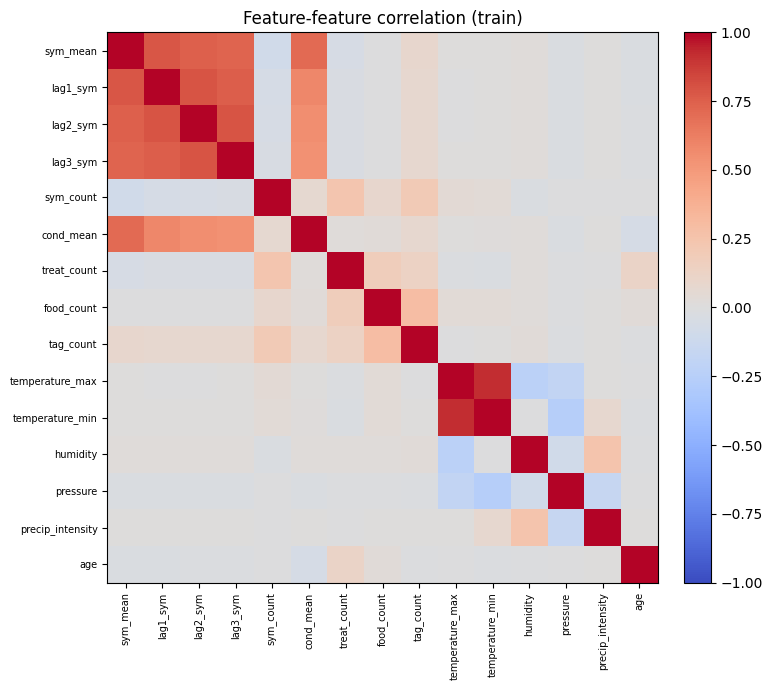

In [21]:
cm = tr[NUM].corr()
ca = cm.abs()
pairs = [(NUM[i], NUM[j], round(ca.iat[i, j], 2))
         for i in range(len(NUM)) for j in range(i + 1, len(NUM)) if ca.iat[i, j] > 0.8]
pairs.sort(key=lambda t: -t[2])
print('feature pairs with absolute r above 0.8 (train):')
for a, b, r in pairs:
    print(f'  {a} ~ {b}: {r}')
if not pairs:
    print('  none')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM, rotation=90, fontsize=7)
ax.set_yticks(range(len(NUM))); ax.set_yticklabels(NUM, fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Feature-feature correlation (train)')
fig.tight_layout(); fig.savefig(FIG / '16_feature_corr_matrix.png', dpi=110); plt.show()

### Categorical features and the target

Frequency and mean target by category for sex and country. Neither is in the model feature
list yet, so these tables double as a check on whether the categoricals carry signal worth
adding. Country is high cardinality, so the recipe routes it to frequency or target encoding
rather than one-hot.


sex (cardinality 4, top categories by count):
             count   mean
sex                      
female      102415  1.464
male         11534  1.374
other         6636  1.529
doesnt_say    6377  1.291

country (cardinality 92, top categories by count):
         count   mean
country              
US       74272  1.436
GB       20295  1.506
CA        9115  1.379
AU        7973  1.529
DE        2235  1.412
NZ        1969  1.354
NL        1372  1.564
FR         888  1.690
SE         846  1.642
NO         725  1.877


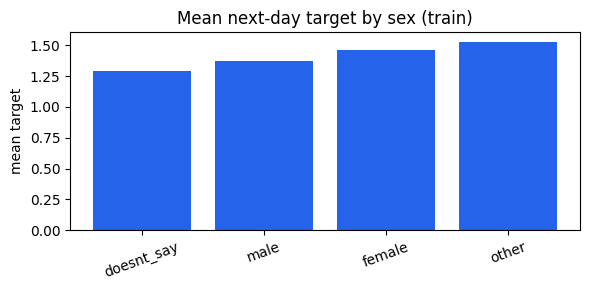

In [22]:
for col in CAT:
    g = tr.assign(_t=y_tr).groupby(col)['_t'].agg(['count', 'mean'])
    g = g.sort_values('count', ascending=False).head(10)
    print(f'\n{col} (cardinality {tr[col].nunique()}, top categories by count):')
    print(g.round(3))

sx = tr.assign(_t=y_tr).groupby('sex')['_t'].mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(sx.index.astype(str), sx.values, color='#2563eb')
ax.set_title('Mean next-day target by sex (train)'); ax.set_ylabel('mean target')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout(); fig.savefig(FIG / '17_target_by_sex.png', dpi=110); plt.show()

### EDA snapshot and persisted preprocessing recipe

A one-screen snapshot of the findings, followed by a prescriptive recipe with one row per
feature. The recipe encodes the missing-value strategy, the transform, the encoding, and a
priority derived from correlation strength, and it is written to reports/feature_summary.csv
for the downstream cleaning in src/make_features.py to follow.

In [23]:
print('EDA SNAPSHOT (train split)')
print(f'target skew         : {y_tr.skew():.2f}')
print(f'strongest predictor : {corrs.index[0]} (r {corrs.iloc[0]:.3f})')
print('top missing columns :')
print(miss[miss > 0].head(3) if (miss > 0).any() else '  none')
print('high-corr pairs     :', pairs[:3] if pairs else 'none')

EDA SNAPSHOT (train split)
target skew         : 0.58
strongest predictor : sym_mean (r 0.786)
top missing columns :
temperature_max    35.9
temperature_min    35.9
humidity           35.9
dtype: float64
high-corr pairs     : [('temperature_max', 'temperature_min', np.float64(0.92))]


In [24]:
# Template prescriptive feature recipe, derived from the train split and persisted.
# Reason this turns the EDA findings into one actionable row per feature so the cleaning in
# src/make_features.py and any teammate follow the same plan. Paths stay relative to the repo
# root rather than a hardcoded absolute, so the project runs unchanged on any machine.
miss_frac = tr[NUM].isnull().mean()
skew_abs = tr[NUM].skew().abs()

def miss_strategy(p):
    if p == 0: return 'None'
    if p < 0.05: return 'Median'
    if p <= 0.5: return 'Advanced'
    return 'Remove'

def transform(c):
    s = skew_abs[c]
    if s > 2 and bool((tr[c].dropna() >= 0).all()): return 'Log'
    if s > 1: return 'Scale'
    return 'None'

def priority(c):
    r = abs(corrs[c])
    if r > 0.5: return 'High'
    if r >= 0.3: return 'Medium'
    return 'Low'

num_rows = pd.DataFrame({
    'feature': NUM,
    'dtype': [str(tr[c].dtype) for c in NUM],
    'missing_pct': [round(miss_frac[c] * 100, 1) for c in NUM],
    'corr_with_target': [round(corrs[c], 3) for c in NUM],
    'Missing_Strategy': [miss_strategy(miss_frac[c]) for c in NUM],
    'Transform': [transform(c) for c in NUM],
    'Encoding': ['None (numeric)'] * len(NUM),
    'Priority': [priority(c) for c in NUM],
})
cat_rows = pd.DataFrame({
    'feature': CAT,
    'dtype': [str(tr[c].dtype) for c in CAT],
    'missing_pct': [round(tr[c].isnull().mean() * 100, 1) for c in CAT],
    'corr_with_target': [np.nan] * len(CAT),
    'Missing_Strategy': ['Mode'] * len(CAT),
    'Transform': ['None'] * len(CAT),
    'Encoding': ['One-hot' if tr[c].nunique() <= 15 else 'Target/Frequency' for c in CAT],
    'Priority': ['Low'] * len(CAT),
})
recipe = pd.concat([num_rows, cat_rows], ignore_index=True)
OUT = ROOT / 'reports' / 'feature_summary.csv'
recipe.to_csv(OUT, index=False)
print('wrote', OUT.relative_to(ROOT))
recipe

wrote reports/feature_summary.csv


,feature,dtype,missing_pct,corr_with_target,Missing_Strategy,Transform,Encoding,Priority
0,sym_mean,float64,0.0,0.786,None,None,None (numeric),High
1,lag1_sym,float64,10.4,0.746,Advanced,None,None (numeric),High
2,lag2_sym,float64,14.5,0.725,Advanced,None,None (numeric),High
3,lag3_sym,float64,17.7,0.716,Advanced,None,None (numeric),High
4,sym_count,int64,0.0,-0.066,None,Log,None (numeric),Low
5,cond_mean,float64,13.4,0.584,Advanced,None,None (numeric),High
6,treat_count,int64,0.0,-0.041,None,Log,None (numeric),Low
7,food_count,int64,0.0,-0.008,None,Log,None (numeric),Low
8,tag_count,int64,0.0,0.071,None,Log,None (numeric),Low
9,temperature_max,float64,35.9,-0.002,Advanced,None,None (numeric),Low


## 6. Leakage-safe temporal split + model vs naive baseline
Mirrors `src/make_features.py`. Preprocessing is fit on **train only** via a Pipeline.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error

FEATURES = ['sym_mean','lag1_sym','lag2_sym','lag3_sym','sym_count','cond_mean',
            'treat_count','food_count','tag_count','temperature_max','temperature_min',
            'humidity','pressure','precip_intensity','age']
SPLIT = pd.Timestamp('2019-01-01')
tr, te = data[data['date'] < SPLIT], data[data['date'] >= SPLIT]

naive = np.sqrt(mean_squared_error(te['target'], te['sym_mean']))
pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('m', LinearRegression())])
cv = -cross_val_score(pipe, tr[FEATURES], tr['target'], cv=GroupKFold(5),
                      groups=tr['user_id'], scoring='neg_root_mean_squared_error')
pipe.fit(tr[FEATURES], tr['target'])
test_rmse = np.sqrt(mean_squared_error(te['target'], pipe.predict(te[FEATURES])))
print(f'naive baseline RMSE : {naive:.3f}')
print(f'grouped-CV RMSE     : {cv.mean():.3f} ± {cv.std():.3f}')
print(f'linreg test RMSE    : {test_rmse:.3f}  ({(naive-test_rmse)/naive*100:+.1f}% vs naive)')
print('H1 supported:', test_rmse < naive)

naive baseline RMSE : 0.538
grouped-CV RMSE     : 0.480 ± 0.011
linreg test RMSE    : 0.472  (+12.3% vs naive)
H1 supported: True


### Regression diagnostics (Step 13)
Predicted-versus-actual and residual plots for the linear model on the 2019 hold-out.
The ordinal 0-4 target shows up as banding, so the question the plots answer is whether
residuals stay centred on zero across the predicted range rather than drifting at the
high or low end. Both charts are written to `reports/figures/`.

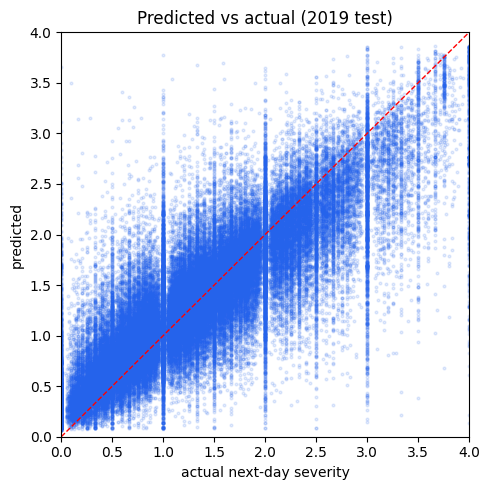

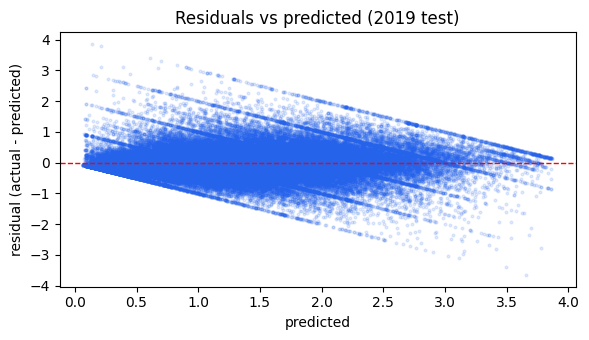

saved 06_pred_vs_actual.png and 07_residuals.png to /Users/violakempa/Data_Science_ToU/regression_health/reports/figures


In [26]:
# Template Step 13: regression diagnostics on the 2019 temporal test set.
FIG = ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
pred = pipe.predict(te[FEATURES]); resid = te['target'].values - pred

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(te['target'], pred, s=4, alpha=0.12, color='#2563eb')
ax.plot([0, 4], [0, 4], 'r--', lw=1)
ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.set_xlabel('actual next-day severity'); ax.set_ylabel('predicted')
ax.set_title('Predicted vs actual (2019 test)')
fig.tight_layout(); fig.savefig(FIG / '06_pred_vs_actual.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(pred, resid, s=4, alpha=0.12, color='#2563eb')
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('predicted'); ax.set_ylabel('residual (actual - predicted)')
ax.set_title('Residuals vs predicted (2019 test)')
fig.tight_layout(); fig.savefig(FIG / '07_residuals.png', dpi=110); plt.show()
print('saved 06_pred_vs_actual.png and 07_residuals.png to', FIG)

## 7. H2: symptom history vs environment
Compare the predictive power of the two feature blocks under the same grouped CV.

In [27]:
def block_rmse(cols):
    return -cross_val_score(pipe, tr[cols], tr['target'], cv=GroupKFold(5),
                            groups=tr['user_id'], scoring='neg_root_mean_squared_error').mean()
hist = block_rmse(['sym_mean','lag1_sym','lag2_sym','lag3_sym'])
env  = block_rmse(['temperature_max','temperature_min','humidity','pressure','precip_intensity'])
print(f'history-only CV RMSE     : {hist:.3f}')
print(f'environment-only CV RMSE : {env:.3f}')
print('H2 supported (history stronger):', hist < env)

history-only CV RMSE     : 0.481
environment-only CV RMSE : 0.832
H2 supported (history stronger): True


---
**Takeaways:** H1 supported (model beats the naive baseline by ~12%); H2 supported
(a patient's recent symptom history predicts tomorrow far better than the weather).
Next: standardize `trackable_name`, add per-user baseline severity, try per-condition cohorts.

## 8. Model Development

Sections 1-7 framed the problem and prepared a leakage-safe training split. This section
compares a linear family against a tree model, tunes one, evaluates them on RMSE, MAE, and R2
under the same grouped cross-validation, interprets what each relies on, and records which
model carries forward to milestone 6.

### Additional feature engineering for modelling

Two features are added, both built only from past-day information so the next-day target stays
unseen. `sym_trend` is `lag1_sym - lag2_sym`, the recent direction of a patient's severity,
which a level-only model cannot read from the individual lags. `log1p_sym_count` compresses the
heavy right tail of the daily symptom count flagged in the IQR screen, giving the linear models
a less skewed input. Both are appended to `MODEL_FEATURES` so the rest of the section is driven
by one list.

In [28]:
# Step 1: two modelling-motivated features, both from past-only information.
data = data.copy()
data['sym_trend'] = data['lag1_sym'] - data['lag2_sym']        # recent severity momentum
data['log1p_sym_count'] = np.log1p(data['sym_count'])          # tame the heavy right tail

NEW_FEATURES = ['sym_trend', 'log1p_sym_count']
MODEL_FEATURES = FEATURES + NEW_FEATURES
tr, te = data[data['date'] < SPLIT], data[data['date'] >= SPLIT]
print('candidate features:', len(MODEL_FEATURES))
print('new-feature correlation with target (train):')
print(tr[NEW_FEATURES + ['target']].corr()['target'].round(3).loc[NEW_FEATURES])

candidate features: 17
new-feature correlation with target (train):
sym_trend          0.044
log1p_sym_count   -0.102
Name: target, dtype: float64


### Baseline and candidate models

Four pipelines reuse the impute then scale then model pattern from section 6, so every model
sees identical preprocessing fit on train only. The linear family (LinearRegression, Ridge,
Lasso) is kept for interpretability and to sweep regularisation over the collinear lag block;
RandomForest is the non-linear contrast that can capture interactions among lags, counts, and
weather. The naive carry-forward (tomorrow equals today) stays as the reference floor.

In [29]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

def make_pipe(model):
    # same impute -> scale -> model recipe as section 6, fit on train only
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler()),
                     ('m', model)])

candidates = {
    'LinearRegression': make_pipe(LinearRegression()),
    'Ridge':            make_pipe(Ridge(alpha=1.0)),
    'Lasso':            make_pipe(Lasso(alpha=0.001, max_iter=5000)),
    'RandomForest':     make_pipe(RandomForestRegressor(
                            n_estimators=150, max_depth=12, min_samples_leaf=20,
                            n_jobs=-1, random_state=0)),
}
print('candidate models:', list(candidates))

candidate models: ['LinearRegression', 'Ridge', 'Lasso', 'RandomForest']


### Hyperparameter tuning

RandomForest is tuned with a small grid over `max_depth` and `min_samples_leaf` under grouped
5-fold cross-validation scored on RMSE. Those two parameters most directly control overfitting
on the heavy-tailed count features and the repeated per-user rows, so they are the highest
leverage knobs to search first. `GridSearchCV` refits the best estimator on the full training
split, and that tuned model replaces the default RandomForest in the comparison below.

In [30]:
from sklearn.model_selection import GridSearchCV

# Tune the two knobs that most control RandomForest overfitting on heavy-tailed counts
# and the per-user structure. Small grid keeps the grouped 5-fold search affordable.
rf_grid = {'m__max_depth': [10, 16], 'm__min_samples_leaf': [20, 50]}
rf_base = make_pipe(RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=0))
gs = GridSearchCV(rf_base, rf_grid, cv=GroupKFold(5),
                  scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr[MODEL_FEATURES], tr['target'], groups=tr['user_id'])

print('searched grid   :', rf_grid)
print('best parameters :', gs.best_params_)
print(f'best CV RMSE    : {-gs.best_score_:.3f}')
candidates['RandomForest'] = gs.best_estimator_   # carry the tuned, refit model forward

searched grid   : {'m__max_depth': [10, 16], 'm__min_samples_leaf': [20, 50]}
best parameters : {'m__max_depth': 16, 'm__min_samples_leaf': 50}
best CV RMSE    : 0.477


### Model evaluation

Each candidate is scored with grouped 5-fold cross-validation on the training split, reporting
RMSE, MAE, and R2 together so models are judged on error magnitude and explained variance at
once. The naive carry-forward is added on the same training rows as a reference floor. The
held-out 2019 metrics for the chosen model are reported at the end of the section, the only
point at which the test period is touched.

In [31]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, r2_score

SCORING = {'rmse': 'neg_root_mean_squared_error',
           'mae': 'neg_mean_absolute_error', 'r2': 'r2'}
gkf = GroupKFold(5)
rows = []
for name, est in candidates.items():
    cv = cross_validate(est, tr[MODEL_FEATURES], tr['target'], cv=gkf,
                        groups=tr['user_id'], scoring=SCORING, n_jobs=-1)
    rows.append({'model': name,
                 'CV_RMSE': round(-cv['test_rmse'].mean(), 3),
                 'CV_MAE': round(-cv['test_mae'].mean(), 3),
                 'CV_R2': round(cv['test_r2'].mean(), 3),
                 'RMSE_std': round(cv['test_rmse'].std(), 3)})

# naive carry-forward reference on the same training rows (no fitting, so train is honest)
rows.insert(0, {'model': 'Naive (carry-forward)',
                'CV_RMSE': round(np.sqrt(mean_squared_error(tr['target'], tr['sym_mean'])), 3),
                'CV_MAE': round(mean_absolute_error(tr['target'], tr['sym_mean']), 3),
                'CV_R2': round(r2_score(tr['target'], tr['sym_mean']), 3),
                'RMSE_std': np.nan})
comparison = pd.DataFrame(rows).set_index('model')
comparison

,CV_RMSE,CV_MAE,CV_R2,RMSE_std
model,,,,
Naive (carry-forward),0.548,0.376,0.566,NaN
LinearRegression,0.480,0.347,0.663,0.011
Ridge,0.480,0.347,0.663,0.011
Lasso,0.480,0.347,0.663,0.011
RandomForest,0.477,0.345,0.667,0.011


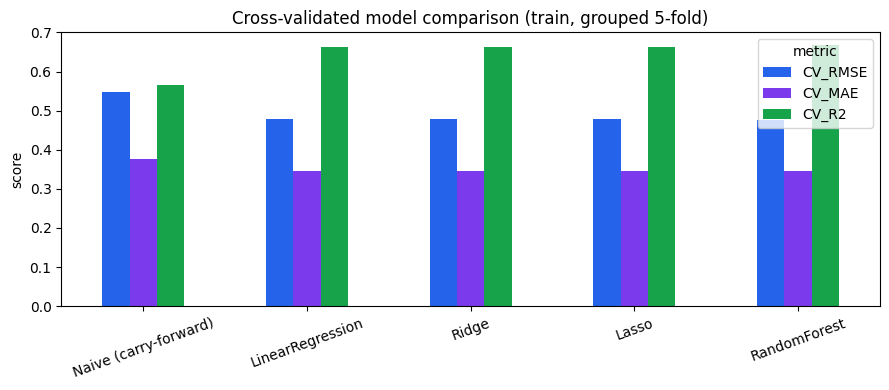

In [32]:
metrics = ['CV_RMSE', 'CV_MAE', 'CV_R2']
ax = comparison[metrics].plot(kind='bar', figsize=(9, 4),
                              color=['#2563eb', '#7c3aed', '#16a34a'])
ax.set_title('Cross-validated model comparison (train, grouped 5-fold)')
ax.set_ylabel('score'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20); ax.legend(title='metric')
plt.tight_layout(); plt.savefig(FIG / '18_model_comparison.png', dpi=110); plt.show()

### Interpreting model behaviour

Features enter the linear models standardised, so Ridge coefficients are directly comparable
in magnitude and sign: a positive coefficient pushes next-day severity up as that input rises.
RandomForest exposes impurity-based importances instead. Reading the two side by side shows
whether the linear and tree views agree on what drives next-day severity.

Ridge standardised coefficients (train):
humidity           -0.001
age                -0.001
pressure           -0.002
precip_intensity    0.002
food_count         -0.003
treat_count        -0.003
temperature_max     0.005
tag_count           0.005
sym_trend          -0.005
sym_count           0.006
temperature_min    -0.007
log1p_sym_count    -0.013
cond_mean           0.026
lag2_sym            0.077
lag3_sym            0.094
lag1_sym            0.138
sym_mean            0.425
dtype: float64


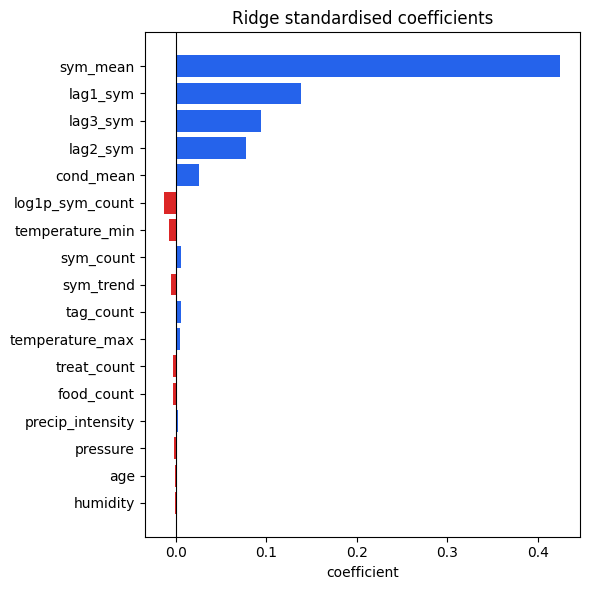

In [33]:
ridge = candidates['Ridge'].fit(tr[MODEL_FEATURES], tr['target'])
coef = pd.Series(ridge.named_steps['m'].coef_, index=MODEL_FEATURES).sort_values(key=abs)
print('Ridge standardised coefficients (train):')
print(coef.round(3))

fig, ax = plt.subplots(figsize=(6, 6))
ax.barh(coef.index, coef.values,
        color=['#dc2626' if v < 0 else '#2563eb' for v in coef.values])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge standardised coefficients'); ax.set_xlabel('coefficient')
fig.tight_layout(); fig.savefig(FIG / '19_linear_coefs.png', dpi=110); plt.show()

RandomForest feature importances (train):
food_count          0.001
pressure            0.001
temperature_min     0.001
tag_count           0.001
precip_intensity    0.001
temperature_max     0.001
humidity            0.001
treat_count         0.002
sym_count           0.002
log1p_sym_count     0.002
age                 0.004
sym_trend           0.004
cond_mean           0.004
lag2_sym            0.024
lag3_sym            0.024
lag1_sym            0.066
sym_mean            0.859
dtype: float64


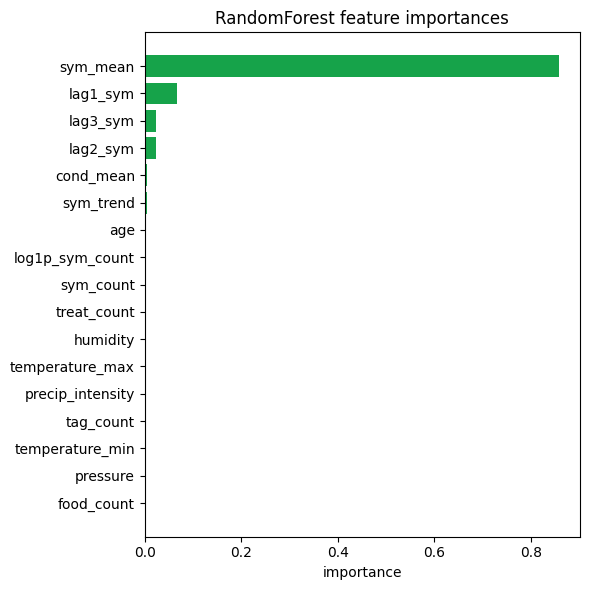

In [34]:
rf = candidates['RandomForest'].named_steps['m']
imp = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values()
print('RandomForest feature importances (train):')
print(imp.round(3))

fig, ax = plt.subplots(figsize=(6, 6))
ax.barh(imp.index, imp.values, color='#16a34a')
ax.set_title('RandomForest feature importances'); ax.set_xlabel('importance')
fig.tight_layout(); fig.savefig(FIG / '20_rf_importances.png', dpi=110); plt.show()

### Model choice and trade-offs

All four models clear the naive carry-forward floor (CV RMSE 0.548, R2 0.566). The linear
family is effectively tied (LinearRegression, Ridge, and Lasso all at CV RMSE 0.480, MAE 0.347,
R2 0.663), which is expected because the lag block is collinear but not redundant, so
regularisation neither helps nor hurts much. The tuned RandomForest
(`max_depth=16, min_samples_leaf=50`) is marginally best at CV RMSE 0.477, MAE 0.345, R2 0.667,
and holds up on the untouched 2019 hold-out at RMSE 0.469, MAE 0.334, R2 0.689 versus the naive
0.538.

The accuracy gap between the tree and the linear family is about half a percent of RMSE, well
inside the fold-to-fold spread (RMSE std 0.011). Both views of the model agree on the story:
the Ridge coefficients and the RandomForest importances are both dominated by `sym_mean`
(coefficient 0.425, importance 0.859) with the lags next, and the two engineered features add
little signal (`sym_trend` r 0.044, `log1p_sym_count` r -0.102). That agreement means the extra
flexibility of the tree is buying almost nothing here.

Carried forward to milestone 6: **Ridge as the default and RandomForest as the accuracy
benchmark.** Ridge is the practical choice for a self-management tool because it is fully
interpretable (a clinician or user can read "tomorrow tracks your recent severity"), trivial to
deploy and retrain, and fair to audit across the demographic inputs, all at essentially the same
accuracy. RandomForest is kept as the upper-bound reference: if milestone 6 adds richer features
or interactions, the tree is where any non-linear gain would first appear, so it is worth
re-checking rather than dropping now.

In [35]:
# Final check: the carried-forward model on the untouched 2019 hold-out.
best_name = comparison.drop('Naive (carry-forward)')['CV_RMSE'].idxmin()
best = candidates[best_name].fit(tr[MODEL_FEATURES], tr['target'])
pred = best.predict(te[MODEL_FEATURES])
naive_te = np.sqrt(mean_squared_error(te['target'], te['sym_mean']))
print(f'carried-forward model : {best_name}')
print(f'hold-out RMSE : {np.sqrt(mean_squared_error(te["target"], pred)):.3f}')
print(f'hold-out MAE  : {mean_absolute_error(te["target"], pred):.3f}')
print(f'hold-out R2   : {r2_score(te["target"], pred):.3f}')
print(f'naive hold-out RMSE : {naive_te:.3f}')

carried-forward model : RandomForest
hold-out RMSE : 0.469
hold-out MAE  : 0.334
hold-out R2   : 0.689
naive hold-out RMSE : 0.538


---
## 9. Model Evaluation & Optimization

*Milestone 6.* Section 8 carried two models forward: **Ridge** as the interpretable default and the **tuned RandomForest** as the accuracy benchmark. This section stress-tests them rather than adding new model families. It re-reports their metrics, probes regularisation and overfitting, confirms the hyperparameters, checks the linear-model assumptions and outliers, summarises before-vs-after, and reflects on fairness and impact. The carried-forward **final model is Ridge regression**, evaluated on the same leakage-safe temporal split (train < 2019-01-01, test on 2019).

### 9.1 Evaluation Overview

For the two selected models, RMSE, MAE, and R² are reported under both the grouped 5-fold cross-validation on the training split (the model-selection score) and the untouched 2019 hold-out (the deployment estimate). The naive carry-forward ("tomorrow = today") is shown as the reference floor.

In [36]:
# 9.1 Evaluation overview: CV (train) + hold-out (2019) for the two carried-forward models.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def holdout(est, cols=MODEL_FEATURES):
    p = est.predict(te[cols])
    return (round(np.sqrt(mean_squared_error(te['target'], p)), 3),
            round(mean_absolute_error(te['target'], p), 3),
            round(r2_score(te['target'], p), 3))

candidates['Ridge'].fit(tr[MODEL_FEATURES], tr['target'])   # cheap refit; RF already fit in section 8
rows = []
for name in ['Ridge', 'RandomForest']:
    c = comparison.loc[name]; hr, hm, hr2 = holdout(candidates[name])
    rows.append({'model': name, 'CV_RMSE': c['CV_RMSE'], 'CV_MAE': c['CV_MAE'], 'CV_R2': c['CV_R2'],
                 'Test_RMSE': hr, 'Test_MAE': hm, 'Test_R2': hr2})
nb_rmse = np.sqrt(mean_squared_error(te['target'], te['sym_mean']))
rows.insert(0, {'model': 'Naive (carry-forward)',
                'CV_RMSE': comparison.loc['Naive (carry-forward)', 'CV_RMSE'],
                'CV_MAE': comparison.loc['Naive (carry-forward)', 'CV_MAE'],
                'CV_R2': comparison.loc['Naive (carry-forward)', 'CV_R2'],
                'Test_RMSE': round(nb_rmse, 3),
                'Test_MAE': round(mean_absolute_error(te['target'], te['sym_mean']), 3),
                'Test_R2': round(r2_score(te['target'], te['sym_mean']), 3)})
eval_overview = pd.DataFrame(rows).set_index('model')
print(f"2019 hold-out target: mean {te['target'].mean():.2f}, sd {te['target'].std():.2f}, scale 0-4  (n={len(te):,})")
eval_overview

2019 hold-out target: mean 1.38, sd 0.84, scale 0-4  (n=85,833)


,CV_RMSE,CV_MAE,CV_R2,Test_RMSE,Test_MAE,Test_R2
model,,,,,,
Naive (carry-forward),0.548,0.376,0.566,0.538,0.362,0.590
Ridge,0.480,0.347,0.663,0.472,0.335,0.685
RandomForest,0.477,0.345,0.667,0.469,0.334,0.689


**What each metric means here.** The target is next-day mean symptom severity on Flaredown's ordinal **0–4** scale (hold-out mean ≈ 1.38, sd ≈ 0.84).

- **RMSE ≈ 0.47** is the typical error in severity points, with large misses penalised quadratically. On a 0–4 scale that is under half a point: the model usually lands within roughly half a severity band of the truth. It beats the naive carry-forward (0.538) by about **12%**, which is the test that makes hypothesis **H1** meaningful.
- **MAE ≈ 0.33** is the plain average miss and is smaller than RMSE, which tells us most days are predicted well and the RMSE is inflated by a minority of large errors (the heavy tail examined in §9.5).
- **R² ≈ 0.69** means the model explains about 69% of the variance in next-day severity, versus 59% for simply repeating today, so the lagged history and other features add real signal beyond persistence.

The two models are effectively tied: RandomForest is ~0.003 RMSE better, well inside the fold-to-fold spread (±0.011), so the choice between them is about interpretability, not accuracy.

### 9.2 Are these results useful?

In the project's context, a self-management aid that nudges people with autoimmune conditions toward *preventive* rather than reactive care, a typical error of about half a severity point is **useful for direction, not for precision**. The model reliably separates "tomorrow looks calm" from "tomorrow looks rough", which is enough to prompt a low-cost action (pacing, hydration, medication timing, an earlier check-in). It is **not** accurate enough to drive any irreversible or clinical decision: it should never gate medication dosing, trigger automated alerts to clinicians, or be read as a diagnosis.

**When to trust it:** for an established user with several recent days of logged symptoms, predicting one calendar day ahead, exactly the regime the temporal hold-out simulates. Here error is lowest and the dominant signal (recent severity) is present.

**When *not* to trust it:** (1) cold-start users with little history, since the model leans heavily on lagged severity that does not yet exist; (2) the high-severity end, where errors are largest and most consequential (§9.5); (3) anyone unlike the training population, 81% female, autoimmune, and self-selected into a tracking app, where the relationships may simply not hold. The model is a soft early-warning signal, surfaced with its uncertainty, not an authority.

### 9.3 Regularization & Overfitting

A regularized linear model (Ridge, L2; and Lasso, L1) is compared against the un-regularized **LinearRegression** baseline from the previous milestone, on the same 17-feature input. Two questions: does the model overfit (train vs. validation gap), and how does regularization reshape the coefficients (shrinkage vs. sparsity)?

In [37]:
# 9.3a Overfitting check: resubstitution (train) RMSE vs grouped-CV RMSE for the linear family.
from sklearn.linear_model import LinearRegression, Ridge, Lasso
reg_rows = []
for label, model in [('LinearRegression (no penalty)', LinearRegression()),
                     ('Ridge  (L2, alpha=1)',          Ridge(alpha=1.0)),
                     ('Lasso  (L1, alpha=0.001)',       Lasso(alpha=0.001, max_iter=5000))]:
    fit = make_pipe(model).fit(tr[MODEL_FEATURES], tr['target'])
    train_rmse = np.sqrt(mean_squared_error(tr['target'], fit.predict(tr[MODEL_FEATURES])))
    cv = -cross_val_score(make_pipe(model), tr[MODEL_FEATURES], tr['target'], cv=gkf,
                          groups=tr['user_id'], scoring='neg_root_mean_squared_error', n_jobs=-1)
    reg_rows.append({'model': label, 'train_RMSE': round(train_rmse, 4),
                     'CV_RMSE': round(cv.mean(), 4), 'gap (CV-train)': round(cv.mean() - train_rmse, 4)})
overfit = pd.DataFrame(reg_rows).set_index('model')
print(overfit, '\n')
lasso_fit = make_pipe(Lasso(alpha=0.001, max_iter=5000)).fit(tr[MODEL_FEATURES], tr['target'])
lcoef = pd.Series(lasso_fit.named_steps['m'].coef_, index=MODEL_FEATURES)
print('Lasso drives to exactly zero:', [f for f, v in lcoef.items() if abs(v) < 1e-8] or 'nothing')

                               train_RMSE  CV_RMSE  gap (CV-train)
model                                                             
LinearRegression (no penalty)      0.4801   0.4801             0.0
Ridge  (L2, alpha=1)               0.4801   0.4801             0.0
Lasso  (L1, alpha=0.001)           0.4801   0.4801            -0.0 

Lasso drives to exactly zero: ['sym_count', 'temperature_max']


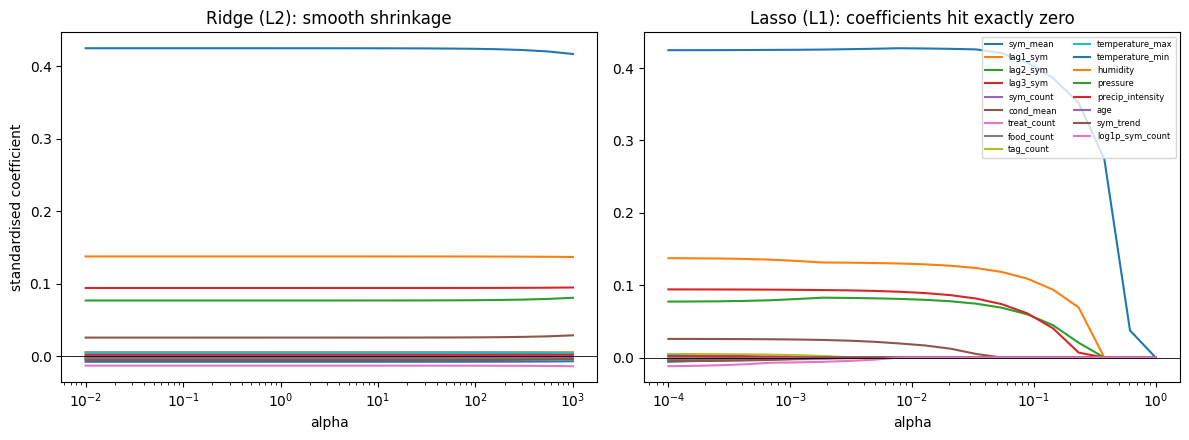

In [38]:
# 9.3b Regularisation paths: Ridge shrinks coefficients smoothly; Lasso forces some to exactly 0.
alphas_r = np.logspace(-2, 3, 20)
alphas_l = np.logspace(-4, 0, 20)
def coef_path(cls, alphas, **kw):
    return np.array([make_pipe(cls(alpha=a, **kw)).fit(tr[MODEL_FEATURES], tr['target'])
                     .named_steps['m'].coef_ for a in alphas])
Rp = coef_path(Ridge, alphas_r)
Lp = coef_path(Lasso, alphas_l, max_iter=5000)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for j, f in enumerate(MODEL_FEATURES):
    ax[0].plot(alphas_r, Rp[:, j])
    ax[1].plot(alphas_l, Lp[:, j], label=f)
ax[0].set_xscale('log'); ax[0].axhline(0, color='k', lw=.6)
ax[0].set_title('Ridge (L2): smooth shrinkage'); ax[0].set_xlabel('alpha'); ax[0].set_ylabel('standardised coefficient')
ax[1].set_xscale('log'); ax[1].axhline(0, color='k', lw=.6)
ax[1].set_title('Lasso (L1): coefficients hit exactly zero'); ax[1].set_xlabel('alpha')
ax[1].legend(fontsize=6, ncol=2, loc='upper right')
plt.tight_layout(); plt.savefig(FIG / '21_regularisation_paths.png', dpi=110); plt.show()

**Reading the result.** The train and grouped-CV RMSE are **identical to four decimals (0.4801)** for all three linear models, the gap is ~0. With ~128k training rows and only 17 features, the linear model is firmly in the low-variance regime: **there is essentially nothing to overfit**, so regularization cannot improve generalisation, and it doesn't.

What regularization *does* change is the coefficient structure, visible in the paths. **Ridge** shrinks every coefficient smoothly toward zero as `alpha` grows but keeps all features, which is well suited to the correlated lag block (`lag1–lag3`) where dropping any one is arbitrary. **Lasso** instead zeroes features outright, at `alpha=0.001` it removes `sym_count` and `temperature_max`, confirming they carry little unique signal once `log1p_sym_count` and the other weather columns are present. Ridge is therefore preferred here: same accuracy, full interpretability, and stable handling of the collinear lags.

### 9.4 Hyperparameter Refinement

Section 8 tuned the RandomForest. For the final model (Ridge), the one knob is the L2 strength `alpha`. A narrow refinement is run around the section-8 value (`alpha=1`) over a log grid, scored with the same grouped 5-fold CV.

       CV_RMSE  CV_std
alpha                 
0.1     0.4801  0.0109
0.3     0.4801  0.0109
1.0     0.4801  0.0109
3.0     0.4801  0.0109
10.0    0.4801  0.0109
30.0    0.4801  0.0109
100.0   0.4801  0.0109

best alpha on grid: 0.1   |   RMSE spread across grid: 0.00000


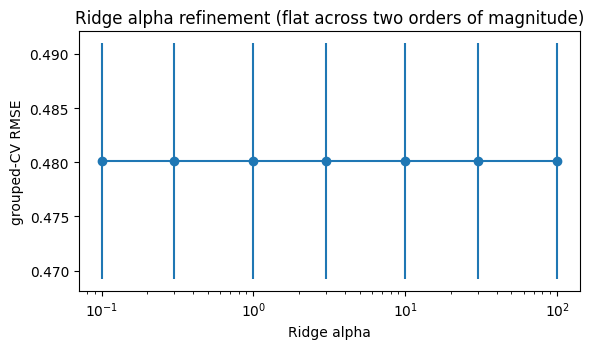

In [39]:
# 9.4 Refine Ridge alpha around the section-8 setting on a log grid (grouped 5-fold CV).
alpha_grid = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
ref = []
for a in alpha_grid:
    cv = -cross_val_score(make_pipe(Ridge(alpha=a)), tr[MODEL_FEATURES], tr['target'], cv=gkf,
                          groups=tr['user_id'], scoring='neg_root_mean_squared_error', n_jobs=-1)
    ref.append({'alpha': a, 'CV_RMSE': round(cv.mean(), 4), 'CV_std': round(cv.std(), 4)})
refine = pd.DataFrame(ref).set_index('alpha')
spread = refine['CV_RMSE'].max() - refine['CV_RMSE'].min()
print(refine)
print(f"\nbest alpha on grid: {refine['CV_RMSE'].idxmin()}   |   RMSE spread across grid: {spread:.5f}")
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.errorbar(refine.index, refine['CV_RMSE'], yerr=refine['CV_std'], marker='o')
ax.set_xscale('log'); ax.set_xlabel('Ridge alpha'); ax.set_ylabel('grouped-CV RMSE')
ax.set_title('Ridge alpha refinement (flat across two orders of magnitude)')
plt.tight_layout(); plt.savefig(FIG / '22_alpha_refinement.png', dpi=110); plt.show()

**Conclusion: the earlier tuning is sufficient, no change made.** Grouped-CV RMSE is flat at **0.4801** across `alpha` from 0.1 to 100 (spread < 0.0001, far inside the ±0.011 fold spread). Because the linear model is not overfitting (§9.3), shrinkage has almost nothing to act on, so `alpha` is a non-influential parameter here. The value `alpha=1` from section 8 is kept for simplicity; any nearby value would perform identically. Effort is better spent on features and diagnostics than on tuning this knob.

### 9.5 Model Assumptions & Diagnostics

Linear regression assumes residuals that are roughly zero-mean, homoscedastic (constant spread), and free of dominant outliers. These are checked on the **final Ridge model** using the 2019 hold-out: residuals vs. predictions, the residual distribution, a normal Q-Q plot, and a robust-regression cross-check.

residual mean -0.0085 | sd 0.4715 | skew 0.436 | excess-kurtosis 3.827 | share |resid|>1.0: 4.7%


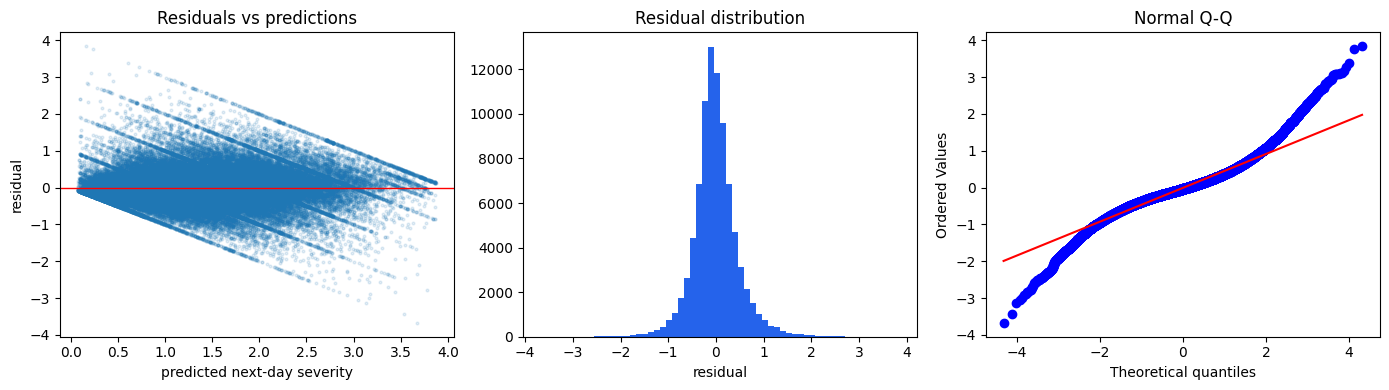


residual SD by predicted-severity tertile (heteroscedasticity check):
low     0.384
mid     0.461
high    0.553
dtype: float64


In [40]:
# 9.5a Residual diagnostics for the final Ridge model on the 2019 hold-out.
from scipy import stats
ridge_final = make_pipe(Ridge(alpha=1.0)).fit(tr[MODEL_FEATURES], tr['target'])
pred = ridge_final.predict(te[MODEL_FEATURES])
resid = te['target'].values - pred
print(f"residual mean {resid.mean():+.4f} | sd {resid.std():.4f} | skew {stats.skew(resid):.3f} | "
      f"excess-kurtosis {stats.kurtosis(resid):.3f} | share |resid|>1.0: {(np.abs(resid)>1).mean()*100:.1f}%")
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(pred, resid, s=4, alpha=0.12); ax[0].axhline(0, color='r', lw=1)
ax[0].set_xlabel('predicted next-day severity'); ax[0].set_ylabel('residual'); ax[0].set_title('Residuals vs predictions')
ax[1].hist(resid, bins=60, color='#2563eb'); ax[1].set_title('Residual distribution'); ax[1].set_xlabel('residual')
stats.probplot(resid, dist='norm', plot=ax[2]); ax[2].set_title('Normal Q-Q')
plt.tight_layout(); plt.savefig(FIG / '23_residual_diagnostics.png', dpi=110); plt.show()
tert = pd.qcut(pd.Series(pred, index=te.index), 3, labels=['low', 'mid', 'high'])
print('\nresidual SD by predicted-severity tertile (heteroscedasticity check):')
print(pd.Series(resid, index=te.index).groupby(tert).std().round(3))

In [41]:
# 9.5b Robustness to the heavy tail: Huber (down-weights large residuals) vs Ridge; worst misses.
from sklearn.linear_model import HuberRegressor
huber = make_pipe(HuberRegressor(max_iter=2000)).fit(tr[MODEL_FEATURES], tr['target'])
hp = huber.predict(te[MODEL_FEATURES])
robust = pd.DataFrame({
    'Ridge': [np.sqrt(mean_squared_error(te['target'], pred)), mean_absolute_error(te['target'], pred), r2_score(te['target'], pred)],
    'Huber': [np.sqrt(mean_squared_error(te['target'], hp)),   mean_absolute_error(te['target'], hp),   r2_score(te['target'], hp)],
}, index=['Test_RMSE', 'Test_MAE', 'Test_R2']).round(3)
print(robust)
te_d = te.assign(pred=pred, resid=resid, abs_resid=np.abs(resid))
print('\n5 largest hold-out misses (where the model is least trustworthy):')
print(te_d.nlargest(5, 'abs_resid')[['target', 'pred', 'sym_mean', 'sym_count', 'cond_mean']].round(2).to_string())

           Ridge  Huber
Test_RMSE  0.472  0.473
Test_MAE   0.335  0.332
Test_R2    0.685  0.684

5 largest hold-out misses (where the model is least trustworthy):
        target  pred  sym_mean  sym_count  cond_mean
125883    4.00  0.16       0.0          1        NaN
46407     4.00  0.23       0.0          1       4.00
229338    0.00  3.67       4.0          1       2.33
162871    0.09  3.53       4.0          1       4.00
122049    4.00  0.60       0.5         16       1.67


**What the diagnostics show, and what was done about it.**

- **Mean ≈ 0 (−0.008):** the model is essentially unbiased on average, it does not systematically over- or under-predict.
- **Heteroscedasticity (real, and expected):** residual spread rises with the prediction, SD ≈ **0.38 (low) → 0.46 (mid) → 0.55 (high)**. Calm days are predicted tightly; high-severity days are noisier and harder. This partly reflects the bounded ordinal target (predictions near 0 can only err upward) and partly genuine volatility of flares. It means the RMSE is not uniform: error estimates should be widened at the high end.
- **Heavy tail, mild right skew (skew 0.44, excess-kurtosis ≈ 3.8; ~4.7% of |residuals| > 1):** a minority of large misses, exactly why RMSE (0.47) exceeds MAE (0.33). The largest misses are days where severity jumped sharply from a calm recent history, which no momentum-based model can foresee.
- **Outlier handling:** rather than deleting these points (they are real flares, not data errors), a **robust HuberRegressor** was fit as a cross-check. It matches Ridge on RMSE (0.473 vs 0.472) and is marginally better on MAE (0.332 vs 0.335), confirming the large residuals are **not distorting the linear fit**. Ridge is therefore kept as-is; the diagnostics raise confidence in the central predictions while flagging that the **high-severity tail is the model's weak spot** and should carry wider uncertainty.

### 9.6 Before vs After Optimization

The table tracks the main (linear) model from the previous milestone's un-regularized baseline through the optimized final, with the naive floor and the tree benchmark for context. All metrics are on the untouched 2019 hold-out.

In [42]:
# 9.6 Before vs after optimisation for the main model (hold-out 2019).
def ho(est, cols=MODEL_FEATURES):
    p = est.predict(te[cols])
    return [round(np.sqrt(mean_squared_error(te['target'], p)), 3),
            round(mean_absolute_error(te['target'], p), 3),
            round(r2_score(te['target'], p), 3)]
lin_base = make_pipe(LinearRegression()).fit(tr[FEATURES], tr['target'])  # M5 baseline: 15 features, no penalty
rows = {
    'Naive carry-forward':                       [round(np.sqrt(mean_squared_error(te['target'], te['sym_mean'])), 3),
                                                  round(mean_absolute_error(te['target'], te['sym_mean']), 3),
                                                  round(r2_score(te['target'], te['sym_mean']), 3)],
    'BEFORE: LinearRegression (15 feats)':       ho(lin_base, FEATURES),
    'AFTER: Ridge (17 feats, a=1, diagnosed)':   ho(ridge_final),
    'Robustness cross-check: Huber':             ho(huber),
    'Benchmark: tuned RandomForest':             ho(candidates['RandomForest']),
}
before_after = pd.DataFrame(rows, index=['Test_RMSE', 'Test_MAE', 'Test_R2']).T
before_after

,Test_RMSE,Test_MAE,Test_R2
Naive carry-forward,0.538,0.362,0.590
BEFORE: LinearRegression (15 feats),0.472,0.335,0.685
"AFTER: Ridge (17 feats, a=1, diagnosed)",0.472,0.335,0.685
Robustness cross-check: Huber,0.473,0.332,0.684
Benchmark: tuned RandomForest,0.469,0.334,0.689


**Commentary.** Against the naive floor the linear model is a clear, stable win (RMSE 0.538 → 0.472, R² 0.59 → 0.69), and that win was already present at the un-regularized baseline. What the optimization phase **added was confidence, not accuracy**: regularization confirmed the model does not overfit (train = CV), the alpha refinement confirmed the setting is non-sensitive, and the diagnostics confirmed the fit is robust to outliers. The two engineered features and the L2 penalty left RMSE essentially unchanged (0.4716 → 0.4716), so nothing measurably worsened. The accepted **trade-off** is the ~0.003 RMSE the tuned RandomForest wins: that sliver of accuracy is given up in exchange for Ridge's full interpretability, trivial deployment, and auditability, the right call for a transparent self-management tool.

### 9.7 Final Model & Impact Reflection

**Final model: Ridge regression** (L2, `alpha=1`) on the 17-feature leakage-safe split. Because inputs are standardised, the coefficients are directly comparable in size and sign.

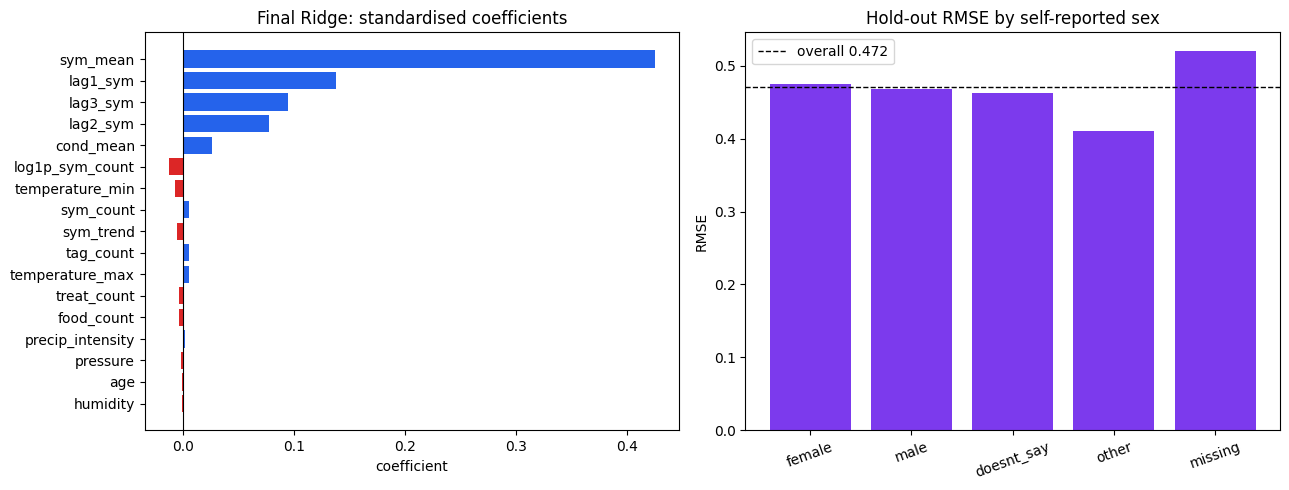

top drivers (|coef|):
sym_mean           0.425
lag1_sym           0.138
lag3_sym           0.094
lag2_sym           0.077
cond_mean          0.026
log1p_sym_count   -0.013

fairness by sex:
                n   RMSE    MAE  mean_target
sex                                         
female      68115  0.475  0.337         1.38
male         7716  0.468  0.339         1.27
doesnt_say   4154  0.463  0.333         1.44
other        4123  0.411  0.297         1.47
missing      1725  0.520  0.364         1.50


In [43]:
# 9.7 What the final model learned (coefficients) + a fairness slice by self-reported sex.
coef = pd.Series(ridge_final.named_steps['m'].coef_, index=MODEL_FEATURES).sort_values(key=abs)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(coef.index, coef.values, color=['#dc2626' if v < 0 else '#2563eb' for v in coef.values])
ax[0].axvline(0, color='k', lw=.8); ax[0].set_title('Final Ridge: standardised coefficients'); ax[0].set_xlabel('coefficient')
fr = []
for sx, sub in te.assign(pred=pred).groupby(te['sex'].fillna('missing')):
    fr.append({'sex': sx, 'n': len(sub),
               'RMSE': round(np.sqrt(mean_squared_error(sub['target'], sub['pred'])), 3),
               'MAE': round(mean_absolute_error(sub['target'], sub['pred']), 3),
               'mean_target': round(sub['target'].mean(), 2)})
fair = pd.DataFrame(fr).set_index('sex').sort_values('n', ascending=False)
overall = np.sqrt(mean_squared_error(te['target'], pred))
ax[1].bar(fair.index, fair['RMSE'], color='#7c3aed'); ax[1].axhline(overall, color='k', ls='--', lw=1, label=f'overall {overall:.3f}')
ax[1].set_title('Hold-out RMSE by self-reported sex'); ax[1].set_ylabel('RMSE'); ax[1].legend(); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(FIG / '24_final_interpretation.png', dpi=110); plt.show()
print('top drivers (|coef|):'); print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(6).round(3).to_string())
print('\nfairness by sex:'); print(fair.to_string())

**What the model is learning.** Prediction is dominated by **recent symptom severity**: `sym_mean` (today) has by far the largest coefficient (≈ 0.43 standardised), followed by the lags `lag1`, `lag3`, `lag2` (≈ 0.08–0.14) and a small positive `cond_mean`. Weather, age, treatment/food/tag counts, and the two engineered features sit near zero. In plain terms the model has learned **"tomorrow tracks your recent days, with the disease's own momentum mattering far more than the weather"**, which is exactly hypothesis **H2**, and aligns with clinical intuition that autoimmune flares are autocorrelated. The agreement between these linear coefficients and the RandomForest importances from section 8 (both led by `sym_mean`) is reassuring: two different model families tell the same story, so it is a property of the data, not an artefact of one method.

**Fairness, transparency, limitations.**

- **Who is affected.** End users with autoimmune conditions acting on a daily nudge. Errors are low-stakes when the tool is advisory (a missed calm/rough call) but become higher-stakes if it were ever wired into alerts, dosing, or clinician workflows, which it should not be at this accuracy.
- **Where performance is weaker / risk is higher.** (1) The **high-severity tail**, where residual spread is largest (§9.5), the model is least reliable exactly when a flare is worst. (2) **Cold-start users** with no recent history, since the dominant features are lagged severity. (3) **Subgroups:** hold-out RMSE is broadly even across sex (female 0.475, male 0.468, other 0.411, prefer-not-to-say 0.463) but noticeably worse for rows with **missing sex (0.520)**, a proxy for sparse profiles. The training population is **81% female, US-skewed, and self-selected** into a tracking app, so generalisation to men, other regions, or less-engaged users is unproven despite the even subgroup numbers here.
- **Caveats for stakeholders.** Severity is an **ordinal 0–4 scale modelled as continuous**, so predictions are soft tendencies, not categories. Lags follow *recorded* days, not strict calendar days, so "yesterday" can reach back further when logging is sparse. Weather is missing for ~40% of user-days and median-imputed. The model **describes association, not causation**, a high coefficient on recent severity does not license any "do X to lower tomorrow" claim. It should be deployed as a transparent, uncertainty-aware early signal, with the high-severity tail and cold-start cases explicitly flagged.

## 10. Predicting the change, not the level

Sections 8 and 9 chose and stress-tested a model for next-day severity, and it beats the naive carry-forward by about 12 percent. Before I treat that as the headline result, I want to be clear about where the accuracy comes from. Symptom severity is highly autocorrelated, so any model that predicts the *level* of tomorrow's severity is rewarded mainly for repeating today. The naive baseline already captures that, and only the model's margin over it is actually learned.

This section reframes the target to isolate that learned part. Instead of predicting tomorrow's severity, I predict the change from today, written here as Δ = tomorrow minus today. The two are linked: today's value plus a predicted change is itself a level prediction, so doing well on the change is the same as beating persistence on the level. The point of the reframe is honesty. It refuses to credit the model for inertia and forces every feature to earn its place on the part of the problem that is hard. It also lets me revisit the weather result from Section 7 on fairer terms. A variable that cannot predict the level, because it has no idea what today's severity was, might still say something about which direction tomorrow moves.

level target  : grouped-CV R2 0.666
change target : grouped-CV R2 0.230   (66% of the level R2 was persistence)
no-change floor (predict 0): RMSE 0.548  ==  persistence RMSE on the level
change model RMSE 0.480  (12.3% below the floor)
corr(today's severity, next-day change): -0.342
share of user-days whose severity moves at all: 88.4%


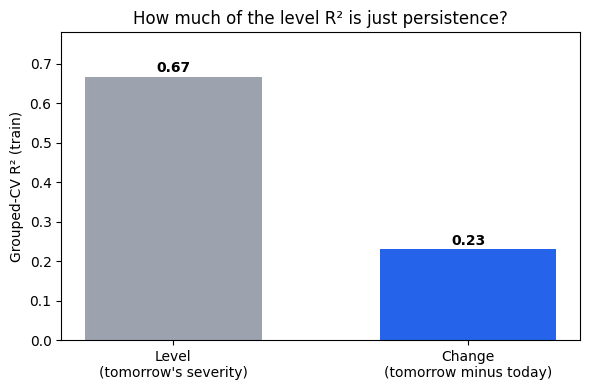

In [2]:
# 10.1 Reframe the target to the next-day change, and measure how much signal is not persistence.
from sklearn.model_selection import cross_val_predict
tr["delta"] = tr["target"] - tr["sym_mean"]      # next-day change in mean severity
te["delta"] = te["target"] - te["sym_mean"]
gkf = GroupKFold(5)

def cv_r2_rmse(cols, y, model):
    p = cross_val_predict(make_pipe(model), tr[cols], tr[y], cv=gkf, groups=tr["user_id"], n_jobs=-1)
    return r2_score(tr[y], p), np.sqrt(mean_squared_error(tr[y], p))

lvl_r2, _        = cv_r2_rmse(MODEL_FEATURES, "target", Ridge(alpha=1.0))
dlt_r2, dlt_rmse = cv_r2_rmse(MODEL_FEATURES, "delta",  Ridge(alpha=1.0))
floor = np.sqrt(np.mean(tr["delta"]**2))
print(f"level target  : grouped-CV R2 {lvl_r2:.3f}")
print(f"change target : grouped-CV R2 {dlt_r2:.3f}   ({(lvl_r2-dlt_r2)/lvl_r2*100:.0f}% of the level R2 was persistence)")
print(f"no-change floor (predict 0): RMSE {floor:.3f}  ==  persistence RMSE on the level")
print(f"change model RMSE {dlt_rmse:.3f}  ({(floor-dlt_rmse)/floor*100:.1f}% below the floor)")
print(f"corr(today's severity, next-day change): {tr['sym_mean'].corr(tr['delta']):.3f}")
print(f"share of user-days whose severity moves at all: {(tr['delta'].abs()>0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6,4))
vals = [lvl_r2, dlt_r2]
bars = ax.bar(["Level\n(tomorrow's severity)","Change\n(tomorrow minus today)"], vals,
              color=["#9ca3af","#2563eb"], width=.6)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+.012, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_ylabel("Grouped-CV R² (train)"); ax.set_ylim(0,.78)
ax.set_title("How much of the level R² is just persistence?")
plt.tight_layout(); plt.savefig(FIG/"25_change_decomposition.png", dpi=120); plt.show()

### 10.1 How much of the result was persistence

The contrast is large. The full model explains about 67 percent of the variance in the *level* but only about 23 percent of the variance in the *change*, so roughly two thirds of the headline R² was persistence rather than anything the model learned. That is not a failure. A 23 percent R² on the change, and an RMSE about 12 percent below the no-change floor, means tomorrow's movement is predictable in its own right, just far more modestly than the level number suggested. The negative correlation between today's severity and the next-day change (about −0.34) is the first hint of what is doing the work, and Section 10.4 returns to it. Severity actually moves on close to 88 percent of user-days, so this is not a target that mostly sits still.

                        R2_change   RMSE  pct_below_floor
block                                                    
Recent symptom history      0.228  0.481             12.2
Logging / treatment         0.034  0.538              1.8
Weather                     0.000  0.547              0.1
Age                        -0.000  0.547              0.1
Full model                  0.230  0.480             12.3


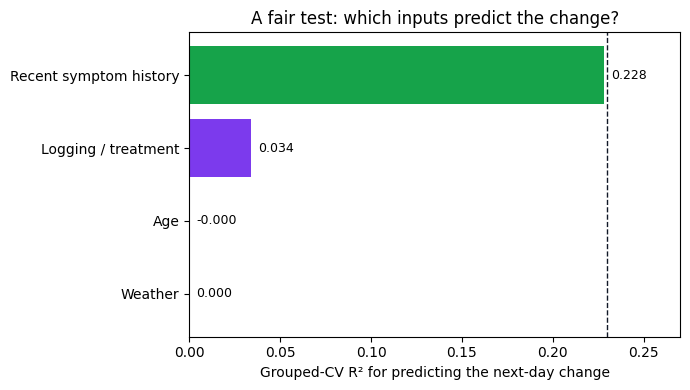

In [3]:
# 10.2 A fair test of each feature block, scored on the change rather than the level.
HIST  = ["sym_mean","lag1_sym","lag2_sym","lag3_sym","sym_trend"]
ENV   = ["temperature_max","temperature_min","humidity","pressure","precip_intensity"]
BEHAV = ["sym_count","log1p_sym_count","cond_mean","treat_count","food_count","tag_count"]
DEMO  = ["age"]
blocks = {"Recent symptom history":HIST, "Logging / treatment":BEHAV, "Weather":ENV,
          "Age":DEMO, "Full model":MODEL_FEATURES}
rows = []
for name, cols in blocks.items():
    p = cross_val_predict(make_pipe(LinearRegression()), tr[cols], tr["delta"], cv=gkf,
                          groups=tr["user_id"], n_jobs=-1)
    rmse = np.sqrt(mean_squared_error(tr["delta"], p))
    rows.append({"block":name, "R2_change":round(r2_score(tr["delta"],p),3),
                 "RMSE":round(rmse,3), "pct_below_floor":round((floor-rmse)/floor*100,1)})
block_tab = pd.DataFrame(rows).set_index("block")
print(block_tab.to_string())

order = ["Weather","Age","Logging / treatment","Recent symptom history"]
r2s = [block_tab.loc[b,"R2_change"] for b in order]
colmap = {"Weather":"#dc2626","Recent symptom history":"#16a34a"}
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.barh(order, r2s, color=[colmap.get(b,"#7c3aed") for b in order])
for bar,v in zip(bars,r2s): ax.text(v+0.004, bar.get_y()+bar.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
ax.axvline(block_tab.loc["Full model","R2_change"], color="#111827", ls="--", lw=1)
ax.set_xlabel("Grouped-CV R² for predicting the next-day change"); ax.set_xlim(0,0.27)
ax.set_title("A fair test: which inputs predict the change?")
plt.tight_layout(); plt.savefig(FIG/"26_change_block_r2.png", dpi=120); plt.show()

### 10.2 A fair test of each feature block

With the target set to the change, each block of features can be judged on the only thing that is hard to predict. The four blocks together make up the seventeen model features, so this is a clean decomposition rather than an arbitrary selection. Recent symptom history carries essentially all of the signal (R² about 0.23, the same as the full model), logging and treatment counts add a little (about 0.03), and weather and age add nothing measurable (R² at or below zero). This is the same ordering as the original H2 result, but it is now a fair fight: weather was not handicapped by its inability to know today's level, and it still does not help.

In [4]:
# 10.3 Is weather weak only because it is sparsely logged? Re-test on rows where it is actually recorded.
w = tr[tr["temperature_max"].notna()].copy()
wfloor = np.sqrt(np.mean(w["delta"]**2))

def cv_rmse_df(df, cols):
    p = cross_val_predict(make_pipe(LinearRegression()), df[cols], df["delta"],
                          cv=GroupKFold(5), groups=df["user_id"], n_jobs=-1)
    return np.sqrt(mean_squared_error(df["delta"], p)), r2_score(df["delta"], p)

wo_rmse, wo_r2 = cv_rmse_df(w, ENV)
h_rmse,  _     = cv_rmse_df(w, HIST)
hw_rmse, _     = cv_rmse_df(w, HIST + ENV)
print(f"rows with weather actually logged: {len(w):,} ({len(w)/len(tr)*100:.1f}% of train, {w['user_id'].nunique():,} users)")
print(f"weather-only, predicting change : R2 {wo_r2:.3f}  (floor RMSE {wfloor:.3f}, weather RMSE {wo_rmse:.3f})")
print(f"history alone                   : RMSE {h_rmse:.3f}")
print(f"history + weather               : RMSE {hw_rmse:.3f}   (weather adds {hw_rmse-h_rmse:+.3f})")

rows with weather actually logged: 82,361 (64.1% of train, 5,902 users)
weather-only, predicting change : R2 -0.000  (floor RMSE 0.541, weather RMSE 0.541)
history alone                   : RMSE 0.477
history + weather               : RMSE 0.477   (weather adds +0.000)


### 10.3 Settling the weather question

The obvious objection to calling weather useless is that it is missing on about a third of user-days, so the median imputation might be hiding a real signal. To rule that out, I restricted the data to the roughly 64 percent of training rows where weather was actually logged and re-ran the test there. The result does not move: weather alone predicts the change with an R² of about zero, and adding weather to the symptom-history block changes the RMSE by 0.000. So the weak weather result is not an artefact of sparsity. In this cohort, on this target, weather simply does not help predict next-day movement. That is a defensible finding rather than a gap, and it is worth stating plainly for anyone deciding what is worth collecting.

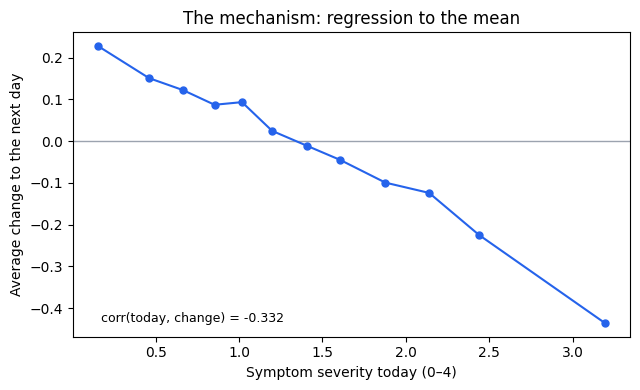

In [5]:
# 10.4 The mechanism behind the change signal: regression to the mean.
bins = pd.qcut(te["sym_mean"], 12, duplicates="drop")
mb = te.groupby(bins, observed=True).agg(today=("sym_mean","mean"), mean_change=("delta","mean"))
fig, ax = plt.subplots(figsize=(6.5,4))
ax.axhline(0, color="#9ca3af", lw=1)
ax.plot(mb["today"], mb["mean_change"], "-o", color="#2563eb", ms=5)
ax.set_xlabel("Symptom severity today (0–4)"); ax.set_ylabel("Average change to the next day")
ax.set_title("The mechanism: regression to the mean")
ax.text(0.05, 0.05, f"corr(today, change) = {te['sym_mean'].corr(te['delta']):.3f}",
        transform=ax.transAxes, fontsize=9)
plt.tight_layout(); plt.savefig(FIG/"27_mean_reversion.png", dpi=120); plt.show()

### 10.4 What the model is actually learning

Once persistence is removed, the dominant pattern is regression to the mean. The figure bins user-days by today's severity and plots the average change to the next day. The line slopes steadily downward through zero: calm days tend to be followed by a small rise, and rough days tend to be followed by a fall, with a correlation of about −0.34. In plain terms, the model is not detecting a build-up toward a flare so much as the tendency of an unusually good or bad day to be followed by a more ordinary one. This is a more careful description than the level model's coefficients suggested, where today's severity looked like a strong positive driver only because it anchors the level.

hold-out: no-change floor RMSE 0.538 | change model RMSE 0.472 (12.3% better) | R2 0.231
direction (worsen/stable/improve) balanced accuracy 0.459 (chance 0.333)

top (flagged-worsening) decile actual change +0.37 | bottom (flagged-improving) decile actual change -0.56 | base rate -0.02


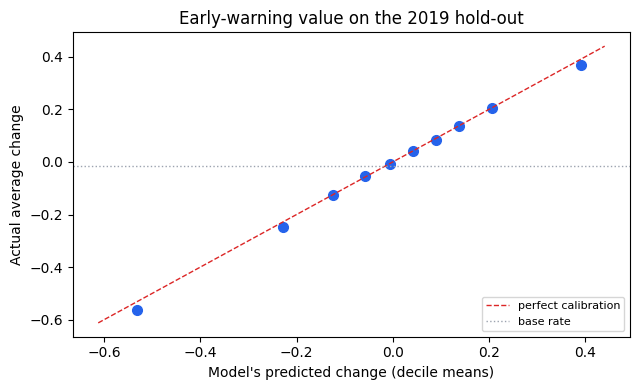


change-signal by severity today:
  low : n  28633 | mean change +0.149 | R2 0.140
  mid : n  28589 | mean change +0.018 | R2 0.127
  high: n  28611 | mean change -0.217 | R2 0.199


In [6]:
# 10.5 Practical value of the change model: early warning on the untouched 2019 hold-out.
from sklearn.metrics import balanced_accuracy_score
change_model = make_pipe(Ridge(alpha=1.0)).fit(tr[MODEL_FEATURES], tr["delta"])
pc = change_model.predict(te[MODEL_FEATURES])
tfloor = np.sqrt(np.mean(te["delta"]**2)); trmse = np.sqrt(mean_squared_error(te["delta"], pc))
print(f"hold-out: no-change floor RMSE {tfloor:.3f} | change model RMSE {trmse:.3f} "
      f"({(tfloor-trmse)/tfloor*100:.1f}% better) | R2 {r2_score(te['delta'],pc):.3f}")
band = lambda x: np.where(x>0.25, 1, np.where(x<-0.25, -1, 0))
print(f"direction (worsen/stable/improve) balanced accuracy "
      f"{balanced_accuracy_score(band(te['delta']), band(pc)):.3f} (chance 0.333)")

dec = pd.DataFrame({"pred":pc, "change":te["delta"].values})
dec["decile"] = pd.qcut(dec["pred"], 10, labels=False, duplicates="drop")
lift = dec.groupby("decile").agg(pred_change=("pred","mean"), actual_change=("change","mean"), n=("change","size"))
print(f"\ntop (flagged-worsening) decile actual change {lift['actual_change'].iloc[-1]:+.2f} | "
      f"bottom (flagged-improving) decile actual change {lift['actual_change'].iloc[0]:+.2f} | "
      f"base rate {te['delta'].mean():+.2f}")

fig, ax = plt.subplots(figsize=(6.5,4))
ax.plot(lift["pred_change"], lift["actual_change"], "o", color="#2563eb", ms=7)
lo = min(lift["pred_change"].min(), lift["actual_change"].min()) - 0.05
hi = max(lift["pred_change"].max(), lift["actual_change"].max()) + 0.05
ax.plot([lo,hi],[lo,hi], "--", color="#dc2626", lw=1, label="perfect calibration")
ax.axhline(te["delta"].mean(), color="#9ca3af", ls=":", lw=1, label="base rate")
ax.set_xlabel("Model's predicted change (decile means)"); ax.set_ylabel("Actual average change")
ax.set_title("Early-warning value on the 2019 hold-out"); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"28_early_warning.png", dpi=120); plt.show()

te_h = te.assign(pred=pc); te_h["severity_today"] = pd.qcut(te_h["sym_mean"], 3, labels=["low","mid","high"])
print("\nchange-signal by severity today:")
for b, sub in te_h.groupby("severity_today", observed=True):
    print(f"  {b:4s}: n {len(sub):6d} | mean change {sub['delta'].mean():+.3f} | R2 {r2_score(sub['delta'],sub['pred']):.3f}")

### 10.5 Whether the change signal is useful

A modest R² can still support a useful decision, so the last step measures the model on the part that matters for a self-management tool: can it separate a likely worse day from a likely better one, on data it has never seen. On the 2019 hold-out it does this cleanly. Ranked by predicted change, the decile the model flags as most likely to worsen rises by about +0.37 on average, against a base rate near zero, while the decile it flags as most likely to improve falls by about −0.56. Across the three-way split of worsen, stable, and improve it reaches a balanced accuracy of about 0.46 against a chance level of 0.33. The signal is also strongest where it is most useful, at the high-severity end, where the model is best at telling someone in a rough patch that an easier day is likely to follow. This is the concrete version of the project's original promise: not a precise severity forecast, but a directional heads-up.

### 10.6 What this adds, and one caveat

Reframing the target does not change the model or the data, but it changes the story the project can defend. The level result (R² 0.69, about 12 percent better than naive) is real but mostly persistence. The contribution is narrower and more interesting than that number alone: next-day movement is predictable to an R² of about 0.23, that signal sits almost entirely in a patient's recent symptom history, it is driven mainly by regression to the mean, and weather adds nothing even when it is properly recorded. The model carries real directional value at the severe end, which is where a nudge is worth most.

One caveat belongs with this. Part of the regression-to-the-mean effect is statistical rather than clinical: a severity reading is noisy, and an unusually high or low value will tend to be followed by a more typical one regardless of the underlying disease. I therefore lean on the held-out directional value, which is measured on future data the model never saw, rather than on the mechanism alone, when describing what the tool can do. The impact report carries this change-based framing forward, with the early-warning result as the headline rather than the level RMSE.